# Avance 1 — Análisis exploratorio del Libro de Registro de Necropsias

**Maestría en Inteligencia Artificial Aplicada (MNA) — Tecnológico de Monterrey**
**Proyecto Integrador — Equipo 23**

## Objetivo

Analizar el *Libro de Registro de Necropsias y Reconocimientos* del Servicio Médico Forense (SEMEFO) de
Querétaro para determinar qué variables de este registro pueden usarse en el cotejo contra las fichas de
búsqueda de personas desaparecidas.

El Proyecto Integrador busca emparejar datos **ante-mortem** (fichas de búsqueda, analizadas en
`02_eda_fichas_busqueda.ipynb`) con datos **post-mortem** (este libro), mediante recuperación por
similitud. Este notebook cubre el lado post-mortem, que hasta ahora no se había analizado.

## Origen de los datos

Registro administrativo de las necropsias y reconocimientos de cadáveres, segmentos y fragmentos
recibidos por el SEMEFO de Querétaro entre enero y septiembre de 2026. Proporcionado en el marco del
convenio de colaboración con la Comisión Local de Búsqueda y la Fiscalía del Estado.

## Tratamiento de datos personales

El archivo contiene nombres, domicilios, carpetas de investigación y folios de certificado, además de los
nombres del personal pericial. Dado que el notebook se publica en un repositorio, se aplica
seudonimización inmediatamente después de la carga (sección 1.2):

| Tipo de dato | Tratamiento |
|---|---|
| Identificación de la persona o del expediente | Se elimina la columna |
| Personal del SEMEFO (peritos, médicos, fotógrafa) | Código anónimo estable (`PERITO_QUE_RECIBE_01`, ...) |
| Texto libre (reseña, descripción de tatuajes, lugar) | Se conserva, pero nunca se imprime su contenido |

Todo el análisis y el CSV de salida trabajan sobre la tabla ya seudonimizada.

## 1. Configuración, carga y seudonimización


In [1]:
%matplotlib inline
import re
import hashlib
import unicodedata
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 80)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 23  # Equipo 23
print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### 1.1 Carga del archivo

El archivo tiene 6 hojas, pero solo `LIBRO` contiene datos: las otras 5 eran tableros de Google Sheets
que quedaron vacíos al exportarse a `.xlsx`. Esto se verifica antes de descartarlas.

La hoja `LIBRO` requiere tres parámetros de carga específicos:

| Parámetro | Motivo |
|---|---|
| `header=1` | La fila 1 son títulos de bloque institucional en celdas combinadas (`DATOS DE NECROPSIA`, `DATOS DE LUGAR`, ...); los nombres de columna están en la fila 2. |
| `usecols="A:AW"` | Más allá de la columna AW hay 17 columnas residuales con apenas 2 celdas con valor en todo el archivo. |
| Filtro por `#` y `FECHA RECEPCIÓN` | El libro está pre-numerado para todo el año; los renglones sin caso real deben excluirse. |

El filtro por dos columnas es necesario porque `dropna(how='all')` no detecta los renglones vacíos: la
columna de días hasta la entrega contiene el literal `'0'` en esas filas.

In [2]:
RUTA = Path("..") / "Datos" / "LIBRO DE REGISTRO DE NECROPSIAS Y RECONOCIMIENTOS 2026 .xlsx"
assert RUTA.exists(), f"No se encontró el archivo en {RUTA.resolve()}"

todas_las_hojas = pd.read_excel(RUTA, sheet_name=None, engine="openpyxl")
print("Hojas encontradas y su tamaño crudo (filas, columnas):")
for nombre, hoja in todas_las_hojas.items():
    print(f"  {nombre!r}: {hoja.shape}")

hojas_vacias = [n for n, h in todas_las_hojas.items() if n != "LIBRO" and h.dropna(how="all").shape[0] == 0]
print(f"\nHojas sin ningún dato aprovechable (confirma que solo 'LIBRO' se usa): {hojas_vacias}")


Hojas encontradas y su tamaño crudo (filas, columnas):
  'LIBRO': (1530, 66)
  'INGRESOS': (0, 0)
  'ENTREGAS': (0, 0)
  'INDICIOS': (0, 0)
  'TIPO DE MUERTE': (0, 0)
  'NECRO X PERITO': (0, 0)

Hojas sin ningún dato aprovechable (confirma que solo 'LIBRO' se usa): ['INGRESOS', 'ENTREGAS', 'INDICIOS', 'TIPO DE MUERTE', 'NECRO X PERITO']


In [3]:
# Carga de la hoja LIBRO con los parámetros correctos
df_crudo = pd.read_excel(RUTA, sheet_name="LIBRO", header=1, usecols="A:AW", engine="openpyxl")

# Columnas con saltos de línea / espacios dobles en el encabezado (p. ej. 'FECHA \nNECROPSIA')
columnas_antes = list(df_crudo.columns)
df_crudo.columns = df_crudo.columns.str.replace(r"\s+", " ", regex=True).str.strip()
cambios_encabezado = [(a, b) for a, b in zip(columnas_antes, df_crudo.columns) if a != b]
print(f"Encabezados con saltos de línea/espacios normalizados: {len(cambios_encabezado)}")
for a, b in cambios_encabezado:
    print(f"  {a!r} -> {b!r}")

print(f"\nShape tras la carga (incluye filas fantasma): {df_crudo.shape}")


Encabezados con saltos de línea/espacios normalizados: 3
  'FECHA \n NECROPSIA' -> 'FECHA NECROPSIA'
  'HORA  \nNECRO' -> 'HORA NECRO'
  'No. \n CERTIFICADO' -> 'No. CERTIFICADO'

Shape tras la carga (incluye filas fantasma): (1529, 49)


In [4]:
# Filtrado de filas fantasma: '#' y 'FECHA RECEPCIÓN' deben existir ambos.
# (NO usar dropna(how='all'): las filas fantasma tienen '0' literal en la columna de días de entrega.)
n_con_numero = df_crudo["#"].notna().sum()
df_crudo = df_crudo[df_crudo["#"].notna() & df_crudo["FECHA RECEPCIÓN"].notna()].reset_index(drop=True)

print(f"Filas con '#' no vacío (consecutivo pre-numerado del año): {n_con_numero}")
print(f"Filas reales tras exigir también 'FECHA RECEPCIÓN' no vacía: {df_crudo.shape[0]}")
assert df_crudo.shape == (731, 49), f"Shape inesperado: {df_crudo.shape}"
print(f"\nShape final verificado: {df_crudo.shape}  (731 casos reales x 49 columnas)")
print("Cobertura temporal (SIN depurar todavía):", df_crudo["FECHA RECEPCIÓN"].min().date(),
      "a", df_crudo["FECHA RECEPCIÓN"].max().date())
print("\n¡La fecha mínima se ve sospechosa (un año antes de lo esperado)! Se investiga y corrige en la")
print("sección 3 (si es un typo evidente de año) y se documenta formalmente en la sección 7.3.")


Filas con '#' no vacío (consecutivo pre-numerado del año): 1100
Filas reales tras exigir también 'FECHA RECEPCIÓN' no vacía: 731

Shape final verificado: (731, 49)  (731 casos reales x 49 columnas)
Cobertura temporal (SIN depurar todavía): 2025-01-12 a 2026-09-27

¡La fecha mínima se ve sospechosa (un año antes de lo esperado)! Se investiga y corrige en la
sección 3 (si es un typo evidente de año) y se documenta formalmente en la sección 7.3.


### 1.2 Seudonimización

Se aplica inmediatamente después de cargar y filtrar, antes de cualquier `head()`, `describe()` o
gráfico, de modo que ninguna salida del notebook pueda contener datos identificables.

El identificador seudónimo `id_registro` se deriva por *hash* SHA-256 del consecutivo, siguiendo el mismo
patrón que `id_ficha()` usa en `01_extraccion_fichas_llm.py` para el lado ante-mortem.

In [5]:
# --- Catálogo de columnas sensibles -----------------------------------------
COLS_PII = [
    "NOMBRE(S) Y APELLIDOS", "DOMICILIO DE RESIDENCIA",
    "CARPETA DE INVESTIGACIÓN", "CADENA DE CUSTODIA",
    "No. CERTIFICADO", "CEDULA PROFESIONAL",
]
COLS_PERSONAL = [
    "PERITO QUE RECIBE", "MÉDICO DE NECROPSIA", "MÉDICO QUE CERTIFICA",
    "MÉDICO QUE ENTREGA", "FOTOGRAFA", "MÉDICO COLEGIADO",
]
COLS_TEXTO_LIBRE = [
    "RESEÑA DEL HECHO", "DESCRIPCIÓN TATUAJES", "LUGAR DONDE OCURRIÓ EL HECHO",
]

assert all(c in df_crudo.columns for c in COLS_PII + COLS_PERSONAL + COLS_TEXTO_LIBRE)

df = df_crudo.copy()

# id_registro: SHA-256 del consecutivo original, truncado a 12 caracteres.
# Mismo patrón que id_ficha() en Notebooks/01_extraccion_fichas_llm.py (hash truncado, determinístico,
# nunca almacena el dato original): aquí la clave es el consecutivo '#', no un folio.
def id_registro_de(numero):
    clave = str(int(numero)).strip().upper()
    return hashlib.sha256(clave.encode()).hexdigest()[:12]

df.insert(0, "id_registro", df["#"].map(id_registro_de))
assert df["id_registro"].is_unique, "Los id_registro deben ser únicos"
df = df.drop(columns=["#"])

# PII directa: eliminar por completo.
df = df.drop(columns=COLS_PII)

# Personal del SEMEFO: código anónimo estable por columna, ordenando valores únicos alfabéticamente
# (no por orden de aparición, para que el código no filtre información temporal).
codigos_personal = {}
for col in COLS_PERSONAL:
    # Quitar acentos ANTES de filtrar A-Z: si no, 'MÉDICO' -> 'M_DICO'
    prefijo = unicodedata.normalize("NFKD", col.upper()).encode("ascii", "ignore").decode()
    prefijo = re.sub(r"[^A-Z]+", "_", prefijo).strip("_")
    valores_unicos = sorted(df[col].dropna().unique())
    mapa = {val: f"{prefijo}_{i+1:02d}" for i, val in enumerate(valores_unicos)}
    codigos_personal[col] = mapa
    df[col] = df[col].map(mapa)  # NaN se preserva (no participó / no se registró)

print("Columnas PII eliminadas:", COLS_PII)
print("\nColumnas de personal anonimizadas (ejemplo de mapeo, columna 'PERITO QUE RECIBE'):")
ejemplo = codigos_personal["PERITO QUE RECIBE"]
print(f"  {len(ejemplo)} personas -> códigos {list(ejemplo.values())[:5]} ...")
print("\nColumnas de texto libre conservadas (NUNCA se imprimen en crudo en este notebook):", COLS_TEXTO_LIBRE)
print(f"\nShape de la tabla seudonimizada de trabajo: {df.shape}")


Columnas PII eliminadas: ['NOMBRE(S) Y APELLIDOS', 'DOMICILIO DE RESIDENCIA', 'CARPETA DE INVESTIGACIÓN', 'CADENA DE CUSTODIA', 'No. CERTIFICADO', 'CEDULA PROFESIONAL']

Columnas de personal anonimizadas (ejemplo de mapeo, columna 'PERITO QUE RECIBE'):
  23 personas -> códigos ['PERITO_QUE_RECIBE_01', 'PERITO_QUE_RECIBE_02', 'PERITO_QUE_RECIBE_03', 'PERITO_QUE_RECIBE_04', 'PERITO_QUE_RECIBE_05'] ...

Columnas de texto libre conservadas (NUNCA se imprimen en crudo en este notebook): ['RESEÑA DEL HECHO', 'DESCRIPCIÓN TATUAJES', 'LUGAR DONDE OCURRIÓ EL HECHO']

Shape de la tabla seudonimizada de trabajo: (731, 43)


In [6]:
# Helper de seguridad: usar SIEMPRE esta función para previsualizar filas, nunca df.head() directo,
# para garantizar que ninguna celda de texto libre se imprima cruda por accidente.
COLS_SENSIBLES_DISPLAY = COLS_TEXTO_LIBRE  # ya no hay PII en df; solo resta blindar el texto libre

def ver_muestra(data, n=5, **kwargs):
    '''Devuelve head()/sample() ocultando las columnas de texto libre (pueden contener nombres propios).'''
    cols_mostrar = [c for c in data.columns if c not in COLS_SENSIBLES_DISPLAY]
    return data[cols_mostrar].head(n, **kwargs) if "n" not in kwargs else data[cols_mostrar].sample(**kwargs)

ver_muestra(df)


,id_registro,FECHA RECEPCIÓN,HORA RECEPCIÓN,PERITO QUE RECIBE,FECHA NECROPSIA,HORA NECRO,MUNICIPIO DONDE OCURRIÓ EL HECHO,"EDAD (AÑOS, MESES, SEMANAS, DÍAS)",SEXO,TIPO DE INDICIO,CONDICIONES EN QUE INGRESA EL INDICIO,INGRESA COMO IDENTIFICADO / NO IDENTIFICADO,ESTADO CIVIL,OCUPACIÓN,CAUSA DE MUERTE,CRONODIAGNOSTICO,TIPO DE MUERTE,HECHO QUE OCASIONÓ LA MUERTE,PARTICIPA SERVICIO PÚBLICO,RELACIONADO A RIÑA,MÉDICO DE NECROPSIA,FOTOGRAFA,MÉDICO COLEGIADO,QUÍMICA,GENÉTICA,BALÍSTICA,PATOLOGÍA,MUESTRAS,DESCRIPCIÓN DE VESTIMENTAS,CICATRICES,TATUAJES,¿SE RECONOCE?,¿EL CUERPO INGRESA A FRIGORIFICOS? INDIQUE EN QUE GAVETA,ESTADO ACTUAL DEL INDICIO,MÉDICO QUE CERTIFICA,FECHA DE ENTREGA,HORA DE ENTREGA DEL CUERPO,MÉDICO QUE ENTREGA,DÍAS HASTA LA ENTREGA O INHUMACIÓN,INHUMADO
0,6b86b273ff34,2026-01-01,03:25:00,PERITO_QUE_RECIBE_10,2026-01-01,06:25:00,QUERÉTARO,14 AÑOS,MUJER,CADÁVER,COMPLETO Y FRESCO,IDENTIFICADO,SOLTERO/A,ESTUDIANTE,EDEMA CEREBRAL SECUNDARIO A ASFIXIA MECANICA POR AHORCAMIENTO,8-12 HORAS,SUICIDIO,ASFIXIA POR AHORCAMIENTO,NO,NO,MEDICO_DE_NECROPSIA_09,NaN,MEDICO_COLEGIADO_01,NO,SI,NO,NO,TOXI + FTA + SU + HV + HA,SI,SI,SI,SI,ENTREGADO,ENTREGADO,MEDICO_QUE_CERTIFICA_18,2026-01-01,11:45:00,MEDICO_QUE_ENTREGA_16,0,NaN
1,d4735e3a265e,2026-01-01,05:05:00,PERITO_QUE_RECIBE_03,2026-01-01,11:00:00,QUERÉTARO,40 AÑOS,HOMBRE,CADÁVER,COMPLETO Y FRESCO,IDENTIFICADO,UNIÓN LIBRE,CHOFER,ASFIXIA MECÁNICA POR OBSTRUCCIÓN DE VIA RESPIRATORIA POR CONTENIDO GASTROALI...,8-10 HORAS,ACCIDENTAL,ASFIXIA POR BRONCOASPIRACIÓN,NO,NO,MEDICO_DE_NECROPSIA_18,NaN,NaN,SI,SI,NO,NO,TOXI + FTA,SI,SI,NO,SI,ENTREGADO,ENTREGADO,MEDICO_QUE_CERTIFICA_18,2026-01-01,22:45:00,MEDICO_QUE_ENTREGA_16,0,NaN
2,4e07408562be,2026-01-01,12:20:00,PERITO_QUE_RECIBE_16,2026-01-01,14:30:00,QUERÉTARO,39 AÑOS,HOMBRE,CADÁVER,COMPLETO Y FRESCO,IDENTIFICADO,SEPARADO,SE IGNORA,TRAUMATISMO CRANEOENCEFÁLICO,6-8 HORAS,ACCIDENTAL,CAÍDA O PRECIPITACIÓN,NO,NO,MEDICO_DE_NECROPSIA_15,NaN,NaN,SI,SI,NO,NO,TOXI + FTA,SI,NO,SI,SI,ENTREGADO,ENTREGADO,MEDICO_QUE_CERTIFICA_15,2026-01-01,19:50:00,MEDICO_QUE_ENTREGA_19,0,NaN
3,4b227777d4dd,2026-01-02,16:25:00,PERITO_QUE_RECIBE_12,2026-01-02,18:00:00,QUERÉTARO,61 AÑOS,HOMBRE,CADÁVER,COMPLETO Y FRESCO,IDENTIFICADO,DIVORCIADO/A,AGRICULTOR,TRANSECCIÓN DE BULBO RAQUÍDEO SECUNDARIA PROYECTIL DISPARADO POR ARMA DE FUE...,6-12 HORAS,SUICIDIO,PROYECTIL DE ARMA DE FUEGO,NO,NO,MEDICO_DE_NECROPSIA_11,NaN,NaN,SI,SI,NO,NO,TOXI + FTA + SU,SI,SI,NO,SI,ENTREGADO,ENTREGADO,MEDICO_QUE_CERTIFICA_11,2026-01-03,00:08:00,MEDICO_QUE_ENTREGA_15,1,NaN
4,7902699be42c,2026-01-04,03:25:00,PERITO_QUE_RECIBE_20,2026-01-04,03:47:00,QUERÉTARO,54 AÑOS,HOMBRE,CADÁVER,COMPLETO Y FRESCO,IDENTIFICADO,CASADO/A,EMPLEADO,NEUMONÍA,6-8 HORAS,ENFERMEDAD,PATOLOGÍA ORGÁNICA,NO,NO,MEDICO_DE_NECROPSIA_19,NaN,NaN,SI,SI,NO,NO,TOXI + FTA,SI,SI,NO,SI,ENTREGADO,ENTREGADO,MEDICO_QUE_CERTIFICA_15,2026-01-04,14:20:00,MEDICO_QUE_ENTREGA_19,0,NaN


## 2. Estructura de los datos

Esta sección describe la tabla tal como llega: después de la seudonimización, pero **antes** de corregir
typos, espacios y categorías duplicadas. Ese saneamiento se aplica en la sección 3, de modo que aquí se
pueda ver el estado real de captura del registro.

In [7]:
print(f"Dimensiones de la tabla de trabajo: {df.shape[0]} filas x {df.shape[1]} columnas\n")
df.info()


Dimensiones de la tabla de trabajo: 731 filas x 43 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 43 columns):
 #   Column                                                    Non-Null Count  Dtype         
---  ------                                                    --------------  -----         
 0   id_registro                                               731 non-null    object        
 1   FECHA RECEPCIÓN                                           731 non-null    datetime64[ns]
 2   HORA RECEPCIÓN                                            726 non-null    object        
 3   PERITO QUE RECIBE                                         730 non-null    object        
 4   FECHA NECROPSIA                                           731 non-null    datetime64[ns]
 5   HORA NECRO                                                730 non-null    object        
 6   MUNICIPIO DONDE OCURRIÓ EL HECHO                          731 non-null    obj

### 2.1 Elementos descartados del archivo original

| Elemento | Motivo |
|---|---|
| Hojas `INGRESOS`, `ENTREGAS`, `INDICIOS`, `TIPO DE MUERTE`, `NECRO X PERITO` | Tableros vacíos tras la exportación desde Google Sheets. |
| Columnas posteriores a `AW` | Residuales, prácticamente sin valores. |
| Renglones sin `#` o sin `FECHA RECEPCIÓN` | Consecutivo anual pre-numerado sin caso capturado. |
| `NOMBRE(S) Y APELLIDOS`, `DOMICILIO DE RESIDENCIA`, `CARPETA DE INVESTIGACIÓN`, `CADENA DE CUSTODIA`, `No. CERTIFICADO`, `CEDULA PROFESIONAL` | Datos personales; eliminados en la seudonimización, no por motivos analíticos. |

A continuación se cuantifican las columnas que, por estar vacías o corruptas, no aportan información
utilizable al análisis.

In [8]:
columnas_candidatas_a_descartar = [
    "INHUMADO",
    "DÍAS HASTA LA ENTREGA O INHUMACIÓN",
    "MÉDICO COLEGIADO",
    "FOTOGRAFA",
]
resumen_descartes = pd.DataFrame({
    "columna": columnas_candidatas_a_descartar,
    "pct_nulo": [round(df[c].isna().mean() * 100, 1) for c in columnas_candidatas_a_descartar],
})
resumen_descartes["razon"] = [
    "100% vacía en los 731 casos reales.",
    "Corrupta: fórmula de Excel convertida a texto; contiene negativos extremos (ver abajo). Se recalculará en la sección 3/7.",
    "Nula en la enorme mayoría de los casos; no aporta señal utilizable.",
    "Nula en más de 2 de cada 3 casos.",
]
resumen_descartes


,columna,pct_nulo,razon
0,INHUMADO,100.0,100% vacía en los 731 casos reales.
1,DÍAS HASTA LA ENTREGA O INHUMACIÓN,0.0,Corrupta: fórmula de Excel convertida a texto; contiene negativos extremos (...
2,MÉDICO COLEGIADO,98.1,Nula en la enorme mayoría de los casos; no aporta señal utilizable.
3,FOTOGRAFA,67.4,Nula en más de 2 de cada 3 casos.


In [9]:
# Evidencia de la corrupción de 'DÍAS HASTA LA ENTREGA O INHUMACIÓN'
col_dias_orig = "DÍAS HASTA LA ENTREGA O INHUMACIÓN"
dias_num = pd.to_numeric(df[col_dias_orig], errors="coerce")
print("dtype original:", df[col_dias_orig].dtype)
print(f"Valores negativos: {(dias_num < 0).sum()} de {dias_num.notna().sum()} no nulos")
print(f"Mínimo: {dias_num.min()}  |  Máximo: {dias_num.max()}")
print("\n'df.info()' la reporta con 0% de nulos porque las filas fantasma tienen '0' como texto, no NaN")
print("-> esta columna se descarta y se recalcula desde las fechas en la sección 7.")


dtype original: object
Valores negativos: 86 de 731 no nulos
Mínimo: -46292  |  Máximo: 215

'df.info()' la reporta con 0% de nulos porque las filas fantasma tienen '0' como texto, no NaN
-> esta columna se descarta y se recalcula desde las fechas en la sección 7.


### 2.2 Diccionario de variables

Se construye una tabla que asocia cada columna con su bloque institucional, su tipo de dato y su **escala
de medición**. La escala determina qué gráfico corresponde a cada variable en la sección 4: una variable
nominal se representa con barras de frecuencia y nunca con histograma; una variable de razón admite
histograma, diagrama de caja y medidas de tendencia central.

In [10]:
# Bloques institucionales tomados de la fila 1 del Excel (celdas combinadas)
bloque_de = {}
for c in ["FECHA RECEPCIÓN", "HORA RECEPCIÓN", "PERITO QUE RECIBE", "FECHA NECROPSIA", "HORA NECRO"]:
    bloque_de[c] = "DATOS DE NECROPSIA"
for c in ["CARPETA DE INVESTIGACIÓN", "CADENA DE CUSTODIA", "MUNICIPIO DONDE OCURRIÓ EL HECHO",
          "LUGAR DONDE OCURRIÓ EL HECHO"]:
    bloque_de[c] = "DATOS DE LUGAR"
for c in ["DOMICILIO DE RESIDENCIA", "NOMBRE(S) Y APELLIDOS", "EDAD (AÑOS, MESES, SEMANAS, DÍAS)", "SEXO"]:
    bloque_de[c] = "DATOS DEL FALLECIDO"
for c in df.columns:
    bloque_de.setdefault(c, "DATOS DEL CUERPO / SEGMENTO / FRAGMENTO ESTUDIADO")
bloque_de["id_registro"] = "IDENTIFICADOR (seudónimo)"

escala_de = {
    "id_registro": "nominal", "FECHA RECEPCIÓN": "intervalo", "HORA RECEPCIÓN": "intervalo",
    "PERITO QUE RECIBE": "nominal", "FECHA NECROPSIA": "intervalo", "HORA NECRO": "intervalo",
    "MUNICIPIO DONDE OCURRIÓ EL HECHO": "nominal", "LUGAR DONDE OCURRIÓ EL HECHO": "nominal (texto libre)",
    "EDAD (AÑOS, MESES, SEMANAS, DÍAS)": "razón (texto a parsear)", "SEXO": "nominal",
    "TIPO DE INDICIO": "nominal", "CONDICIONES EN QUE INGRESA EL INDICIO": "nominal",
    "INGRESA COMO IDENTIFICADO / NO IDENTIFICADO": "nominal (binaria)", "ESTADO CIVIL": "nominal",
    "OCUPACIÓN": "nominal (alta cardinalidad)", "CAUSA DE MUERTE": "nominal (alta cardinalidad)",
    "CRONODIAGNOSTICO": "razón (texto a parsear)", "TIPO DE MUERTE": "nominal",
    "HECHO QUE OCASIONÓ LA MUERTE": "nominal", "RESEÑA DEL HECHO": "nominal (texto libre)",
    "PARTICIPA SERVICIO PÚBLICO": "nominal (binaria)", "RELACIONADO A RIÑA": "nominal (binaria)",
    "MÉDICO DE NECROPSIA": "nominal", "FOTOGRAFA": "nominal", "MÉDICO COLEGIADO": "nominal",
    "QUÍMICA": "nominal (binaria)", "GENÉTICA": "nominal (binaria)", "BALÍSTICA": "nominal (binaria)",
    "PATOLOGÍA": "nominal (binaria)", "MUESTRAS": "nominal (multi-etiqueta)",
    "DESCRIPCIÓN DE VESTIMENTAS": "nominal (binaria, NO es texto)", "CICATRICES": "nominal (binaria, NO es texto)",
    "TATUAJES": "nominal (binaria)", "DESCRIPCIÓN TATUAJES": "nominal (texto libre)",
    "¿SE RECONOCE?": "nominal (binaria)", "¿EL CUERPO INGRESA A FRIGORIFICOS? INDIQUE EN QUE GAVETA": "nominal (mixta: estatus + ubicación)",
    "ESTADO ACTUAL DEL INDICIO": "nominal", "MÉDICO QUE CERTIFICA": "nominal",
    "FECHA DE ENTREGA": "intervalo", "HORA DE ENTREGA DEL CUERPO": "intervalo",
    "MÉDICO QUE ENTREGA": "nominal", "DÍAS HASTA LA ENTREGA O INHUMACIÓN": "razón (corrupta, se recalcula)",
    "INHUMADO": "nominal (100% vacía)",
}
rol_de = {
    "id_registro": "ID", "RESEÑA DEL HECHO": "texto libre", "DESCRIPCIÓN TATUAJES": "texto libre",
    "LUGAR DONDE OCURRIÓ EL HECHO": "texto libre",
    "PERITO QUE RECIBE": "personal (anonimizado)", "MÉDICO DE NECROPSIA": "personal (anonimizado)",
    "MÉDICO QUE CERTIFICA": "personal (anonimizado)", "MÉDICO QUE ENTREGA": "personal (anonimizado)",
    "FOTOGRAFA": "personal (anonimizado)", "MÉDICO COLEGIADO": "personal (anonimizado)",
    "FECHA RECEPCIÓN": "fecha", "FECHA NECROPSIA": "fecha", "FECHA DE ENTREGA": "fecha",
    "HORA RECEPCIÓN": "hora", "HORA NECRO": "hora", "HORA DE ENTREGA DEL CUERPO": "hora",
}
for c in df.columns:
    rol_de.setdefault(c, "categórica")

diccionario_variables = pd.DataFrame({
    "columna": df.columns,
    "bloque_institucional": [bloque_de.get(c, "-") for c in df.columns],
    "tipo_dato_pandas": [str(df[c].dtype) for c in df.columns],
    "escala_de_medicion": [escala_de.get(c, "nominal") for c in df.columns],
    "rol": [rol_de.get(c, "categórica") for c in df.columns],
})
diccionario_variables


,columna,bloque_institucional,tipo_dato_pandas,escala_de_medicion,rol
0,id_registro,IDENTIFICADOR (seudónimo),object,nominal,ID
1,FECHA RECEPCIÓN,DATOS DE NECROPSIA,datetime64[ns],intervalo,fecha
2,HORA RECEPCIÓN,DATOS DE NECROPSIA,object,intervalo,hora
3,PERITO QUE RECIBE,DATOS DE NECROPSIA,object,nominal,personal (anonimizado)
4,FECHA NECROPSIA,DATOS DE NECROPSIA,datetime64[ns],intervalo,fecha
5,HORA NECRO,DATOS DE NECROPSIA,object,intervalo,hora
6,MUNICIPIO DONDE OCURRIÓ EL HECHO,DATOS DE LUGAR,object,nominal,categórica
7,LUGAR DONDE OCURRIÓ EL HECHO,DATOS DE LUGAR,object,nominal (texto libre),texto libre
8,"EDAD (AÑOS, MESES, SEMANAS, DÍAS)",DATOS DEL FALLECIDO,object,razón (texto a parsear),categórica
9,SEXO,DATOS DEL FALLECIDO,object,nominal,categórica


### 2.3 Descriptivos y frecuencia de clases

`describe(include='all')` se calcula sobre todas las columnas **excepto** las de texto libre: para esas,
los estadísticos `top` y `freq` imprimirían la cadena más repetida, y aunque en la práctica suele ser un
valor de relleno, el notebook se publica en un repositorio. El texto libre se caracteriza por separado,
solo con longitudes y cobertura.

In [11]:
cols_no_texto_libre = [c for c in df.columns if c not in COLS_TEXTO_LIBRE]
tabla_describe = df[cols_no_texto_libre].describe(include="all").T
tabla_describe


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_registro,731,731,6b86b273ff34,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FECHA RECEPCIÓN,731,NaN,NaN,NaN,2026-05-13 05:42:45.800273664,2025-01-12 00:00:00,2026-03-08 00:00:00,2026-05-13 00:00:00,2026-07-20 12:00:00,2026-09-27 00:00:00,NaN
HORA RECEPCIÓN,726,409,02:20:00,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PERITO QUE RECIBE,730,23,PERITO_QUE_RECIBE_20,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FECHA NECROPSIA,731,NaN,NaN,NaN,2026-05-13 19:57:42.106702848,2026-01-01 00:00:00,2026-03-08 00:00:00,2026-05-13 00:00:00,2026-07-20 12:00:00,2026-09-27 00:00:00,NaN
HORA NECRO,730,269,18:00:00,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MUNICIPIO DONDE OCURRIÓ EL HECHO,731,12,QUERÉTARO,560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"EDAD (AÑOS, MESES, SEMANAS, DÍAS)",730,227,21 AÑOS,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SEXO,731,3,HOMBRE,567,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIPO DE INDICIO,731,6,CADÁVER,662,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Caracterización segura de las columnas de texto libre: solo longitudes y cobertura, nunca contenido.
def caracterizar_texto_libre(serie):
    no_vacio = serie.dropna().astype(str).str.strip()
    no_vacio = no_vacio[no_vacio != ""]
    longitudes = no_vacio.str.len()
    return pd.Series({
        "n_total": len(serie),
        "n_no_vacio": len(no_vacio),
        "pct_no_vacio": round(100 * len(no_vacio) / len(serie), 1),
        "longitud_media": round(longitudes.mean(), 1) if len(longitudes) else np.nan,
        "longitud_mediana": longitudes.median() if len(longitudes) else np.nan,
        "longitud_maxima": longitudes.max() if len(longitudes) else np.nan,
    })

tabla_texto_libre = pd.DataFrame({c: caracterizar_texto_libre(df[c]) for c in COLS_TEXTO_LIBRE}).T
tabla_texto_libre


,n_total,n_no_vacio,pct_no_vacio,longitud_media,longitud_mediana,longitud_maxima
RESEÑA DEL HECHO,731.0,729.0,99.7,58.7,54.0,170.0
DESCRIPCIÓN TATUAJES,731.0,219.0,30.0,320.5,124.0,3956.0
LUGAR DONDE OCURRIÓ EL HECHO,731.0,730.0,99.9,53.7,56.0,152.0


In [13]:
# Frecuencia de clases de TODAS las columnas categóricas (excluyendo texto libre, fechas/horas e id)
cols_categoricas_todas = [
    c for c in df.columns
    if c not in COLS_TEXTO_LIBRE
    and c not in ["id_registro", "FECHA RECEPCIÓN", "FECHA NECROPSIA", "FECHA DE ENTREGA",
                  "HORA RECEPCIÓN", "HORA NECRO", "HORA DE ENTREGA DEL CUERPO"]
    and df[c].dtype == object
]
print(f"{len(cols_categoricas_todas)} columnas categóricas identificadas.\n")
for c in cols_categoricas_todas:
    n_cat = df[c].nunique(dropna=True)
    print(f"--- {c}  ({n_cat} categorías, {df[c].isna().sum()} nulos) ---")
    vc = df[c].value_counts(dropna=False).head(8)
    print(vc.to_string())
    print()


32 columnas categóricas identificadas.

--- PERITO QUE RECIBE  (23 categorías, 1 nulos) ---
PERITO QUE RECIBE
PERITO_QUE_RECIBE_20    70
PERITO_QUE_RECIBE_10    68
PERITO_QUE_RECIBE_12    65
PERITO_QUE_RECIBE_05    62
PERITO_QUE_RECIBE_14    60
PERITO_QUE_RECIBE_18    58
PERITO_QUE_RECIBE_22    54
PERITO_QUE_RECIBE_23    52

--- MUNICIPIO DONDE OCURRIÓ EL HECHO  (12 categorías, 0 nulos) ---
MUNICIPIO DONDE OCURRIÓ EL HECHO
QUERÉTARO           560
EL MARQUÉS          109
CORREGIDORA          42
SAN JUAN DEL RIO      7
PEDRO ESCOBEDO        4
CADEREYTA             2
AMEALCO               2
OTRO ESTADO           1

--- EDAD (AÑOS, MESES, SEMANAS, DÍAS)  (227 categorías, 1 nulos) ---
EDAD (AÑOS, MESES, SEMANAS, DÍAS)
21 AÑOS    13
31 AÑOS    13
53 AÑOS    13
36 AÑOS    12
27 AÑOS    12
24 AÑOS    11
20 AÑOS    11
30 AÑOS    11

--- SEXO  (3 categorías, 0 nulos) ---
SEXO
HOMBRE           567
MUJER            119
INDETERMINADO     45

--- TIPO DE INDICIO  (6 categorías, 0 nulos) ---
TIPO DE 

### 2.4 Valores faltantes

Se reporta primero el conteo de nulos que reconoce `pandas`. La sección 2.5 muestra que esta cifra
subestima el faltante real.

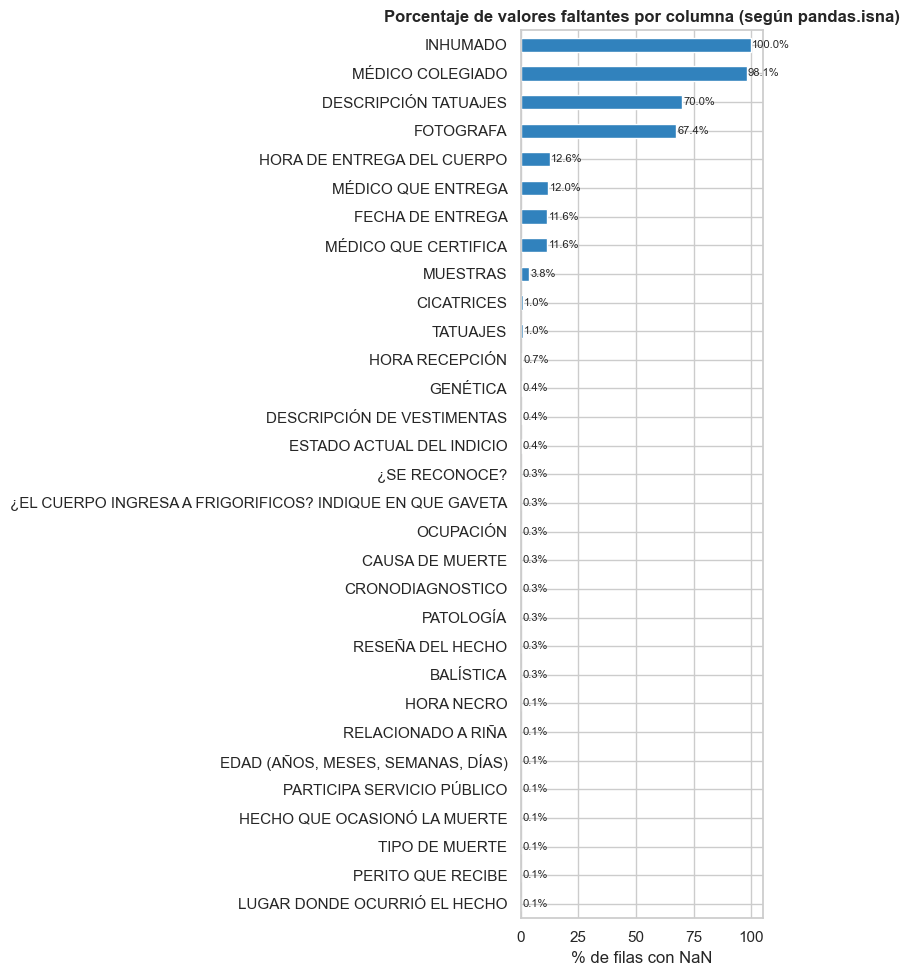

In [14]:
faltantes_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
faltantes_pct = faltantes_pct[faltantes_pct > 0]

fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(faltantes_pct))))
faltantes_pct.sort_values().plot.barh(ax=ax, color="#3182bd")
ax.set(title="Porcentaje de valores faltantes por columna (según pandas.isna)",
       xlabel="% de filas con NaN", ylabel="")
for i, v in enumerate(faltantes_pct.sort_values()):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()


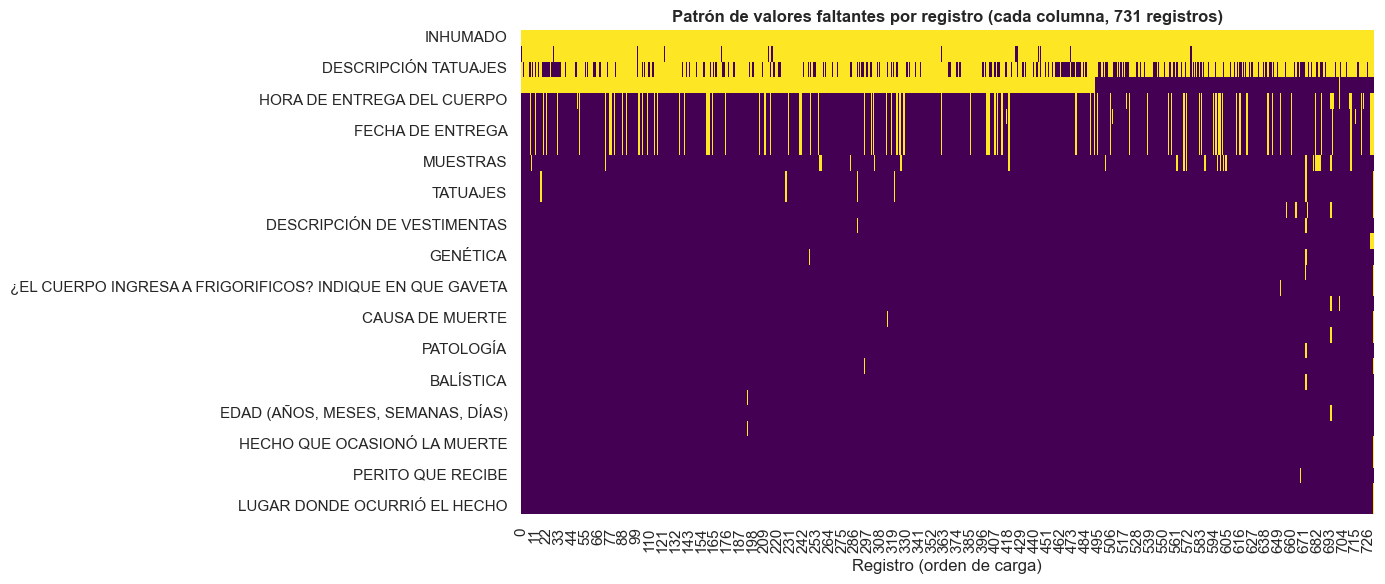

In [15]:
# Heatmap de patrones de ausencia (isna()) para ver si las columnas faltan "en bloque"
fig, ax = plt.subplots(figsize=(14, 6))
orden_cols = faltantes_pct.index.tolist()
sns.heatmap(df[orden_cols].isna().T, cmap="viridis", cbar=False, ax=ax)
ax.set(title="Patrón de valores faltantes por registro (cada columna, 731 registros)", xlabel="Registro (orden de carga)")
plt.tight_layout()
plt.show()


**Resultado.** El patrón de ausencia no es uniforme: se concentra en tres columnas de la etapa de
entrega y en dos de personal. `INHUMADO` está vacía en los 731 casos, `MÉDICO COLEGIADO` en el 98.1% y
`FOTOGRAFA` en el 67.4%. Las columnas del bloque de entrega (`FECHA DE ENTREGA`, `MÉDICO QUE ENTREGA`,
`HORA DE ENTREGA`) faltan de forma conjunta en unos 85 casos, lo cual es coherente: corresponden a
cuerpos que aún no han sido entregados, no a errores de captura. El resto del registro está capturado de
forma notablemente completa, con menos del 1% de nulos en casi todas las columnas.

### 2.5 Faltantes disfrazados

Varias columnas expresan "no se sabe" o "no aplica" con literales de texto (`SE IGNORA`, `N/A`,
`NINGUNO`) en lugar de dejar la celda vacía, por lo que `isna()` no los detecta. Aquí se cuantifican; su
tratamiento se decide en la sección 7.1.

La distinción relevante es entre dos tipos de literal:

- **Faltante disfrazado**: `SE IGNORA`, `N/A`, `NA` y sus variantes con typo. Equivalen a ausencia de dato.
- **Categoría pericial legítima**: `INDETERMINADO` en `SEXO`, `TIPO DE MUERTE`, `HECHO QUE OCASIONÓ LA
  MUERTE` y `CRONODIAGNOSTICO` es una conclusión del perito ("no se pudo determinar"), y `NINGUNA` en
  `MUESTRAS` significa que no se tomaron muestras. Ambos son información y no deben convertirse en nulos.

In [16]:
LITERALES_FALTANTE_DISFRAZADO = {"SE IGNORA", "SE INGORA", "SE GNORA", "N/A", "NA", "NO APLICA", "NINGUNO"}
LITERALES_CATEGORIA_LEGITIMA = {"INDETERMINADO", "INDETERMINADA", "NINGUNA"}

def tasa_literal(serie, literales):
    s = serie.dropna().astype(str).str.strip().str.upper()
    return (s.isin(literales)).sum()

filas_disfrazados = []
for c in cols_categoricas_todas:
    n_disfrazado = tasa_literal(df[c], LITERALES_FALTANTE_DISFRAZADO)
    if n_disfrazado > 0:
        filas_disfrazados.append({
            "columna": c, "n_literal_no_dato": n_disfrazado,
            "pct_sobre_731": round(100 * n_disfrazado / len(df), 1),
            "pct_nulo_isna": round(df[c].isna().mean() * 100, 1),
        })

tabla_faltantes_disfrazados = pd.DataFrame(filas_disfrazados).sort_values("pct_sobre_731", ascending=False)
tabla_faltantes_disfrazados


,columna,n_literal_no_dato,pct_sobre_731,pct_nulo_isna
1,ESTADO CIVIL,167,22.8,0.0
2,OCUPACIÓN,165,22.6,0.3
4,RELACIONADO A RIÑA,84,11.5,0.1
3,PARTICIPA SERVICIO PÚBLICO,79,10.8,0.1
0,"EDAD (AÑOS, MESES, SEMANAS, DÍAS)",3,0.4,0.1
5,MUESTRAS,2,0.3,3.8


In [17]:
print("Verificación: 'INDETERMINADO' como categoría pericial legítima, NO como NaN")
for c in ["SEXO", "TIPO DE MUERTE", "HECHO QUE OCASIONÓ LA MUERTE", "CRONODIAGNOSTICO"]:
    n = df[c].astype(str).str.strip().str.upper().str.contains("INDETERMINAD", na=False).sum()
    print(f"  {c}: {n} casos marcados INDETERMINADO/A ({100*n/len(df):.1f}%) -> se conservan como categoría")

n_ninguna_muestras = df["MUESTRAS"].astype(str).str.strip().str.upper().isin(["NINGUNA", "NINGUNO", "NIGUNA", "NNINGUNO"]).sum()
print(f"\n  MUESTRAS: {n_ninguna_muestras} casos sin toma de muestras (NINGUNA/variantes) -> es información, no ausencia de ella")


Verificación: 'INDETERMINADO' como categoría pericial legítima, NO como NaN
  SEXO: 45 casos marcados INDETERMINADO/A (6.2%) -> se conservan como categoría
  TIPO DE MUERTE: 26 casos marcados INDETERMINADO/A (3.6%) -> se conservan como categoría
  HECHO QUE OCASIONÓ LA MUERTE: 30 casos marcados INDETERMINADO/A (4.1%) -> se conservan como categoría
  CRONODIAGNOSTICO: 26 casos marcados INDETERMINADO/A (3.6%) -> se conservan como categoría

  MUESTRAS: 88 casos sin toma de muestras (NINGUNA/variantes) -> es información, no ausencia de ella


## 3. Saneamiento

Esta sección corrige únicamente problemas mecánicos de captura —espacios sobrantes, typos de digitación,
encabezados con saltos de línea— sin los cuales los conteos de frecuencia saldrían fragmentados. Las
decisiones que requieren criterio (tratamiento de faltantes, atípicos y alta cardinalidad) se aplican en
la sección 7.

### 3.1 Espacios sobrantes

Si una celda contiene `'ENTREGADO '` y otra `'ENTREGADO'`, `value_counts()` las cuenta como categorías
distintas. Se mide la extensión del problema antes de corregirlo.

In [18]:
cols_texto_todas = [c for c in df.columns if df[c].dtype == object]
antes_espacios = {}
for c in cols_texto_todas:
    s = df[c].dropna().astype(str)
    con_espacios = (s != s.str.strip()) | s.str.contains(r"  +", regex=True)
    if con_espacios.sum() > 0:
        antes_espacios[c] = (con_espacios.sum(), round(100 * con_espacios.sum() / len(s), 1))

tabla_espacios = pd.DataFrame(antes_espacios, index=["n_celdas_con_espacios_sobrantes", "pct"]).T
tabla_espacios = tabla_espacios.sort_values("pct", ascending=False)
print(f"{len(tabla_espacios)} columnas con espacios sobrantes; las 10 más afectadas:")
tabla_espacios.head(10)


12 columnas con espacios sobrantes; las 10 más afectadas:


,n_celdas_con_espacios_sobrantes,pct
DESCRIPCIÓN TATUAJES,103.0,47.0
RESEÑA DEL HECHO,215.0,29.5
CAUSA DE MUERTE,203.0,27.8
CRONODIAGNOSTICO,177.0,24.3
LUGAR DONDE OCURRIÓ EL HECHO,167.0,22.9
OCUPACIÓN,164.0,22.5
"EDAD (AÑOS, MESES, SEMANAS, DÍAS)",153.0,21.0
MUESTRAS,114.0,16.2
¿EL CUERPO INGRESA A FRIGORIFICOS? INDIQUE EN QUE GAVETA,54.0,7.4
PARTICIPA SERVICIO PÚBLICO,26.0,3.6


In [19]:
# Cardinalidad ANTES de limpiar (para el reporte antes/después)
cols_a_reportar_cardinalidad = [
    "CAUSA DE MUERTE", "OCUPACIÓN", "ESTADO CIVIL", "CONDICIONES EN QUE INGRESA EL INDICIO",
    "¿EL CUERPO INGRESA A FRIGORIFICOS? INDIQUE EN QUE GAVETA", "MUESTRAS", "ESTADO ACTUAL DEL INDICIO",
]
cardinalidad_antes = {c: df[c].nunique(dropna=True) for c in cols_a_reportar_cardinalidad}


### 3.2 Normalización de espacios y typos

Se aplica recorte y colapso de espacios a todas las columnas de texto. Sobre las categóricas se colapsan
además los typos de digitación detectados al perfilar el archivo; cada entrada del diccionario de
correcciones corresponde a un valor observado en los datos, no a una lista genérica. El texto libre solo
se recorta, nunca se re-categoriza.

In [20]:
def limpiar_espacios(texto):
    if pd.isna(texto):
        return texto
    return re.sub(r"\s+", " ", str(texto)).strip()

for c in cols_texto_todas:
    df[c] = df[c].map(limpiar_espacios)

# Typos de digitación verificados contra los datos (no genéricos): mismo patrón que SINONIMOS en
# Notebooks/01_extraccion_fichas_llm.py (mapeo plano valor-crudo -> valor-canónico).
TYPOS_GLOBALES = {
    "SE INGORA": "SE IGNORA", "SE GNORA": "SE IGNORA",
    "N0": "NO", "NIO": "NO",
    "ENTEGADO": "ENTREGADO", "ENRREGADO": "ENTREGADO", "ENTGREGADO": "ENTREGADO",
    "ENTRAGADO": "ENTREGADO", "ENTREGDO": "ENTREGADO", "ENTRTEGADO": "ENTREGADO",
    "ENTREGANDO": "ENTREGADO", "ENTREGADA": "ENTREGADO",
    "ANTROPOLOGIA": "ANTROPOLOGÍA",
    "INCOMPLETO Y QUEMADO": "QUEMADO E INCOMPLETO",
    "NIGUNA": "NINGUNA", "NNINGUNO": "NINGUNO",
    "TXOI": "TOXI",
}

def colapsar_typos(texto):
    if pd.isna(texto):
        return texto
    clave = str(texto).upper()
    return TYPOS_GLOBALES.get(clave, texto)

for c in cols_categoricas_todas:
    df[c] = df[c].map(colapsar_typos)

cardinalidad_despues = {c: df[c].nunique(dropna=True) for c in cols_a_reportar_cardinalidad}
tabla_cardinalidad = pd.DataFrame({
    "categorias_antes": cardinalidad_antes,
    "categorias_despues": cardinalidad_despues,
})
tabla_cardinalidad["categorias_eliminadas"] = tabla_cardinalidad["categorias_antes"] - tabla_cardinalidad["categorias_despues"]
print("Reporte antes/después de cardinalidad (evidencia cuantificada del saneamiento):")
tabla_cardinalidad


Reporte antes/después de cardinalidad (evidencia cuantificada del saneamiento):


,categorias_antes,categorias_despues,categorias_eliminadas
CAUSA DE MUERTE,354,328,26
OCUPACIÓN,182,161,21
ESTADO CIVIL,7,7,0
CONDICIONES EN QUE INGRESA EL INDICIO,7,6,1
¿EL CUERPO INGRESA A FRIGORIFICOS? INDIQUE EN QUE GAVETA,77,65,12
MUESTRAS,188,172,16
ESTADO ACTUAL DEL INDICIO,3,3,0


### 3.3 Variables derivadas

Tres variables numéricas están capturadas como texto semi-estructurado y deben parsearse antes de poder
analizarse:

| Columna | Formatos presentes |
|---|---|
| `EDAD (AÑOS, MESES, SEMANAS, DÍAS)` | `"39 AÑOS"`, `"55-60 AÑOS"` (rango), `"1 MES"`, `"24 SDG"` (semanas de gestación), `"INDETERMINADO"` |
| `CRONODIAGNOSTICO` | `"4-6 HORAS"` (rango), `"2 MESES"`, `"NO VALORABLE"` |
| `DÍAS HASTA LA ENTREGA O INHUMACIÓN` | Corrupta; se recalcula desde `FECHA DE ENTREGA − FECHA NECROPSIA` |

Las semanas de gestación no son comparables con la edad postnatal, por lo que el parseo conserva la
unidad original en una columna categórica paralela. Los valores indeterminados se convierten a `NaN` en
la variable numérica, pero el motivo queda registrado en esa misma columna de unidad.

In [21]:
def parsear_edad(texto):
    if pd.isna(texto):
        return np.nan, "SIN_DATO"
    t = re.sub(r"\s+", " ", str(texto).upper().strip()).rstrip(".")
    if "INDETERMINAD" in t or "IGNORA" in t:
        return np.nan, "INDETERMINADO_SE_IGNORA"
    if "SDG" in t:  # semanas de gestación (fetos): no comparable a edad postnatal
        nums = [float(x) for x in re.findall(r"\d+\.?\d*", t)]
        return (np.mean(nums) if nums else np.nan), "SEMANAS_GESTACION_FETO"
    nums = re.findall(r"\d+\.?\d*", t)
    if not nums:
        return np.nan, "SIN_PARSEAR"
    valor = float(np.mean([float(n) for n in nums]))
    if "AÑO" in t:
        return valor, "AÑOS"
    if "MES" in t:
        return valor / 12.0, "MESES"
    if "SEMANA" in t:
        return valor / 52.0, "SEMANAS"
    if "DIA" in t or "DÍA" in t:
        return valor / 365.0, "DIAS"
    return valor, "SIN_UNIDAD_SE_ASUME_AÑOS"

def parsear_crono(texto):
    if pd.isna(texto):
        return np.nan, "SIN_DATO"
    t = re.sub(r"\s+", " ", str(texto).upper().strip())
    if "INDETERMINAD" in t or "VALORABLE" in t:
        return np.nan, "INDETERMINADO_NO_VALORABLE"
    nums = re.findall(r"\d+\.?\d*", t)
    if not nums:
        return np.nan, "SIN_PARSEAR"
    valor = float(np.mean([float(n) for n in nums]))
    if "SEMANA" in t:
        return valor * 7 * 24, "SEMANAS"
    if "MES" in t:
        return valor * 30 * 24, "MESES"
    if "DIA" in t or "DÍA" in t:
        return valor * 24, "DIAS"
    if "HORA" in t or "HRS" in t:
        return valor, "HORAS"
    return np.nan, "SIN_PARSEAR"

df[["edad_anios", "edad_unidad_original"]] = df["EDAD (AÑOS, MESES, SEMANAS, DÍAS)"].apply(
    lambda x: pd.Series(parsear_edad(x))
)
df[["horas_crono", "crono_unidad_original"]] = df["CRONODIAGNOSTICO"].apply(
    lambda x: pd.Series(parsear_crono(x))
)

print("edad_unidad_original:")
print(df["edad_unidad_original"].value_counts().to_string())
print(f"\nedad_anios parseada en {df['edad_anios'].notna().sum()} de {len(df)} casos")
print("\ncrono_unidad_original:")
print(df["crono_unidad_original"].value_counts().to_string())
print(f"\nhoras_crono parseada en {df['horas_crono'].notna().sum()} de {len(df)} casos")


edad_unidad_original:
edad_unidad_original
AÑOS                        662
SEMANAS_GESTACION_FETO       27
INDETERMINADO_SE_IGNORA      21
MESES                         8
SEMANAS                       5
DIAS                          4
SIN_UNIDAD_SE_ASUME_AÑOS      2
SIN_PARSEAR                   1
SIN_DATO                      1

edad_anios parseada en 708 de 731 casos

crono_unidad_original:
crono_unidad_original
HORAS                         654
DIAS                           39
INDETERMINADO_NO_VALORABLE     28
MESES                           4
SIN_PARSEAR                     3
SIN_DATO                        2
SEMANAS                         1

horas_crono parseada en 698 de 731 casos


### 3.4 Corrección de un error de año

La cobertura temporal impresa en la sección 1.1 arrojó una fecha mínima de recepción un año anterior a lo
esperado. Un solo registro con esa fecha desplazaría toda la serie temporal, por lo que se identifica y
corrige antes del análisis.

In [22]:
# Un gap de >300 días entre recepción y necropsia es fisicamente implausible (el resto del libro tiene
# gaps de 0 a pocos días); es el patrón de un typo de año en FECHA RECEPCIÓN (2025 por 2026).
gap_dias = (df["FECHA NECROPSIA"] - df["FECHA RECEPCIÓN"]).dt.days
mask_typo_anio = gap_dias.abs() > 300
print(f"Casos con gap |necropsia - recepción| > 300 días: {int(mask_typo_anio.sum())}")
display(df.loc[mask_typo_anio, ["FECHA RECEPCIÓN", "FECHA NECROPSIA"]])

df["fecha_recepcion_corregida_anio"] = mask_typo_anio
if mask_typo_anio.any():
    # Se corrige el AÑO de FECHA RECEPCIÓN para que coincida con el de FECHA NECROPSIA (no al revés):
    # en el resto del libro la recepción ocurre el mismo día o unos pocos días antes de la necropsia,
    # nunca un año antes; el dato más confiable aquí es el día/mes (coinciden: 12/enero en ambas fechas),
    # y el campo que contiene el error es el año de recepción.
    idx = df.index[mask_typo_anio]
    for i in idx:
        f_recep, f_necro = df.loc[i, "FECHA RECEPCIÓN"], df.loc[i, "FECHA NECROPSIA"]
        df.loc[i, "FECHA RECEPCIÓN"] = f_recep.replace(year=f_necro.year)
    print("\nCorregido. Verificación posterior:")
    display(df.loc[idx, ["FECHA RECEPCIÓN", "FECHA NECROPSIA", "fecha_recepcion_corregida_anio"]])

print(f"\nCobertura temporal corregida: {df['FECHA RECEPCIÓN'].min().date()} a {df['FECHA RECEPCIÓN'].max().date()}")


Casos con gap |necropsia - recepción| > 300 días: 1


,FECHA RECEPCIÓN,FECHA NECROPSIA
29,2025-01-12,2026-01-12



Corregido. Verificación posterior:


,FECHA RECEPCIÓN,FECHA NECROPSIA,fecha_recepcion_corregida_anio
29,2026-01-12,2026-01-12,True



Cobertura temporal corregida: 2026-01-01 a 2026-09-27


In [23]:
# Timestamps combinando fecha + hora, y recálculo de días hasta la entrega desde fechas reales
# El saneamiento de la seccion 3 convierte algunas horas de datetime.time a texto ('03:25:00').
# Se normalizan ambos casos a hora decimal; si no, todas las derivadas de hora salen vacias.
def hora_a_decimal(h):
    if pd.isna(h):
        return np.nan
    if hasattr(h, "hour"):
        return h.hour + h.minute / 60
    m = re.match(r"^\s*(\d{1,2})[:.](\d{2})", str(h))
    if not m or int(m.group(1)) > 23 or int(m.group(2)) > 59:
        return np.nan
    return int(m.group(1)) + int(m.group(2)) / 60


def combinar_fecha_hora(fecha, hora):
    if pd.isna(fecha):
        return pd.NaT
    dec = hora_a_decimal(hora)
    if pd.isna(dec):
        return fecha
    return fecha.normalize() + pd.Timedelta(hours=dec)

df["ts_recepcion"] = [combinar_fecha_hora(f, h) for f, h in zip(df["FECHA RECEPCIÓN"], df["HORA RECEPCIÓN"])]
df["ts_necropsia"] = [combinar_fecha_hora(f, h) for f, h in zip(df["FECHA NECROPSIA"], df["HORA NECRO"])]
df["ts_entrega"] = [combinar_fecha_hora(f, h) for f, h in zip(df["FECHA DE ENTREGA"], df["HORA DE ENTREGA DEL CUERPO"])]

df["dias_entrega"] = (df["FECHA DE ENTREGA"] - df["FECHA NECROPSIA"]).dt.days
df["hora_recepcion_num"] = df["HORA RECEPCIÓN"].map(hora_a_decimal)
assert df["hora_recepcion_num"].notna().sum() > 600, "hora_recepcion_num quedó vacía: revisar el parseo de horas"

# Longitudes de texto libre como columnas (ya se resumieron en 2.3; aquí se materializan para la sección 4)
for c, nombre in [("RESEÑA DEL HECHO", "resena_longitud"), ("DESCRIPCIÓN TATUAJES", "desc_tatuajes_longitud")]:
    vals = df[c].astype(str).str.strip()
    vals = vals.where(~vals.str.upper().isin(["N/A", "NA", "NAN", "NONE", ""]), np.nan)
    df[nombre] = vals.str.len()

print("Variables derivadas creadas: edad_anios, horas_crono, ts_recepcion, ts_necropsia, ts_entrega,")
print("dias_entrega (recalculada), hora_recepcion_num, resena_longitud, desc_tatuajes_longitud")
print(f"\ndias_entrega (recalculada) -> describe:\n{df['dias_entrega'].describe()}")


Variables derivadas creadas: edad_anios, horas_crono, ts_recepcion, ts_necropsia, ts_entrega,
dias_entrega (recalculada), hora_recepcion_num, resena_longitud, desc_tatuajes_longitud

dias_entrega (recalculada) -> describe:
count    646.000000
mean       4.380805
std       19.510614
min       -1.000000
25%        0.000000
50%        1.000000
75%        1.000000
max      215.000000
Name: dias_entrega, dtype: float64


### 3.5 Descriptivos de las variables numéricas derivadas

El `describe()` de la sección 2.3 resume las variables tal como vienen del archivo, donde ninguna es
numérica: edad, cronodiagnóstico y días hasta la entrega están capturados como texto o vienen corruptos.
Una vez parseados en 3.3 y 3.4, se completa aquí el cuadro de estadísticas descriptivas del conjunto, de
modo que todas las variables —categóricas, de texto libre y numéricas— queden caracterizadas.


In [24]:
COLS_NUMERICAS_DERIVADAS = ["edad_anios", "dias_entrega", "horas_crono", "hora_recepcion_num",
                            "resena_longitud", "desc_tatuajes_longitud"]

tabla_descriptivos_num = df[COLS_NUMERICAS_DERIVADAS].describe().T
tabla_descriptivos_num["asimetria"] = df[COLS_NUMERICAS_DERIVADAS].skew()
tabla_descriptivos_num["curtosis"] = df[COLS_NUMERICAS_DERIVADAS].kurt()
tabla_descriptivos_num["n_faltantes"] = df[COLS_NUMERICAS_DERIVADAS].isna().sum()
tabla_descriptivos_num["pct_faltantes"] = (df[COLS_NUMERICAS_DERIVADAS].isna().mean() * 100).round(1)
tabla_descriptivos_num.round(2)

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis,n_faltantes,pct_faltantes
edad_anios,708.0,42.23,20.00,0.01,27.50,41.00,57.00,93.00,0.12,-0.57,23,3.1
dias_entrega,646.0,4.38,19.51,-1.00,0.00,1.00,1.00,215.00,7.32,60.99,85,11.6
horas_crono,698.0,25.65,137.58,3.00,6.00,7.00,10.00,2520.00,13.39,202.20,33,4.5
hora_recepcion_num,723.0,13.08,6.95,0.00,7.29,14.05,18.79,23.97,-0.32,-1.06,8,1.1
resena_longitud,729.0,58.59,26.91,13.00,38.00,54.00,71.00,170.00,1.14,1.65,2,0.3
desc_tatuajes_longitud,219.0,318.17,517.96,1.00,51.00,124.00,339.50,3887.00,3.43,14.88,512,70.0


## 4. Análisis univariante

Cada variable se grafica según la escala de medición declarada en el diccionario de la sección 2.2:
histograma y diagrama de caja para variables de razón, barras de frecuencia para nominales, top-N más
cola para nominales de alta cardinalidad, barras apiladas para banderas binarias, y distribución de
longitudes para texto libre.

### 4.1 Variables numéricas

Se reportan histograma, diagrama de caja y asimetría para las cuatro variables de razón derivadas en la
sección 3.3.

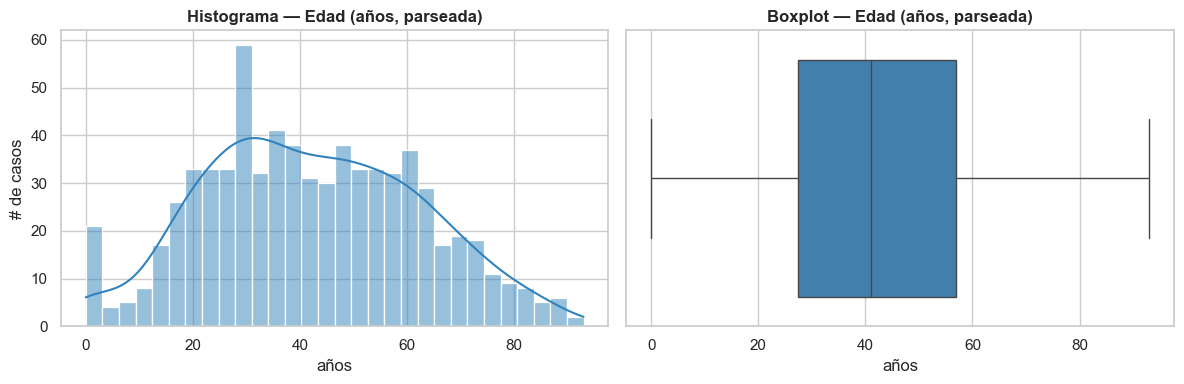

Edad (años, parseada): n=708 | media=42.23 | mediana=41.00 | desv_std=20.00 | asimetría(skew)=0.12 | min=0.01 | max=93.00


In [25]:
def analizar_numerica(serie, titulo, unidad=""):
    datos = serie.dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(datos, bins=30, ax=axes[0], color="#3182bd", kde=True)
    axes[0].set(title=f"Histograma — {titulo}", xlabel=unidad, ylabel="# de casos")
    sns.boxplot(x=datos, ax=axes[1], color="#3182bd")
    axes[1].set(title=f"Boxplot — {titulo}", xlabel=unidad)
    plt.tight_layout()
    plt.show()
    print(f"{titulo}: n={len(datos)} | media={datos.mean():.2f} | mediana={datos.median():.2f} | "
          f"desv_std={datos.std():.2f} | asimetría(skew)={datos.skew():.2f} | "
          f"min={datos.min():.2f} | max={datos.max():.2f}")

analizar_numerica(df["edad_anios"], "Edad (años, parseada)", "años")


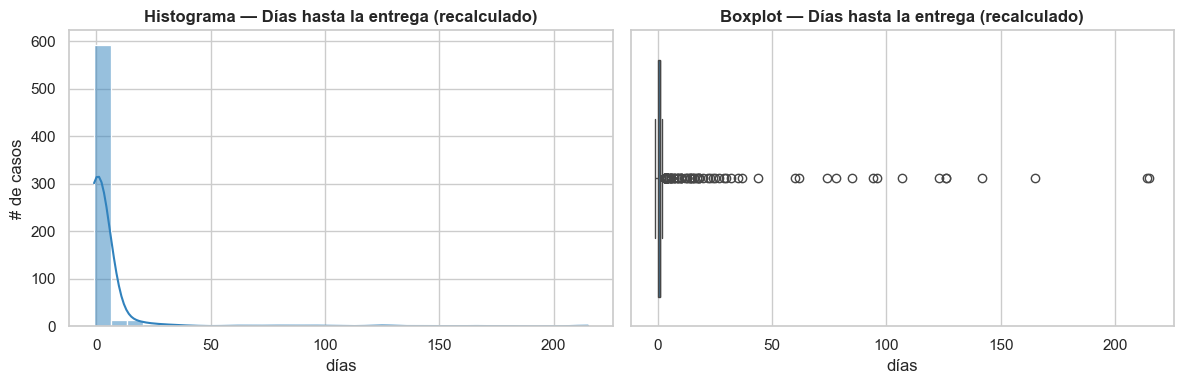

Días hasta la entrega (recalculado): n=646 | media=4.38 | mediana=1.00 | desv_std=19.51 | asimetría(skew)=7.32 | min=-1.00 | max=215.00


In [26]:
analizar_numerica(df["dias_entrega"], "Días hasta la entrega (recalculado)", "días")


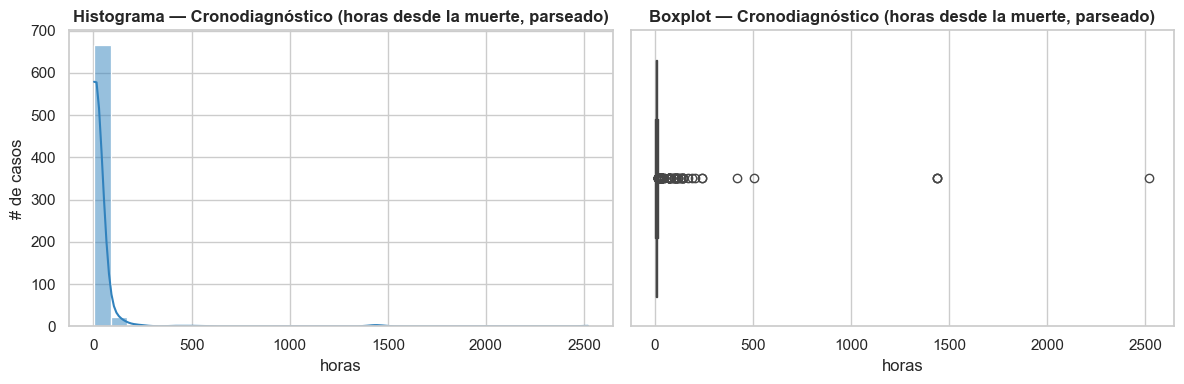

Cronodiagnóstico (horas desde la muerte, parseado): n=698 | media=25.65 | mediana=7.00 | desv_std=137.58 | asimetría(skew)=13.39 | min=3.00 | max=2520.00


In [27]:
analizar_numerica(df["horas_crono"], "Cronodiagnóstico (horas desde la muerte, parseado)", "horas")


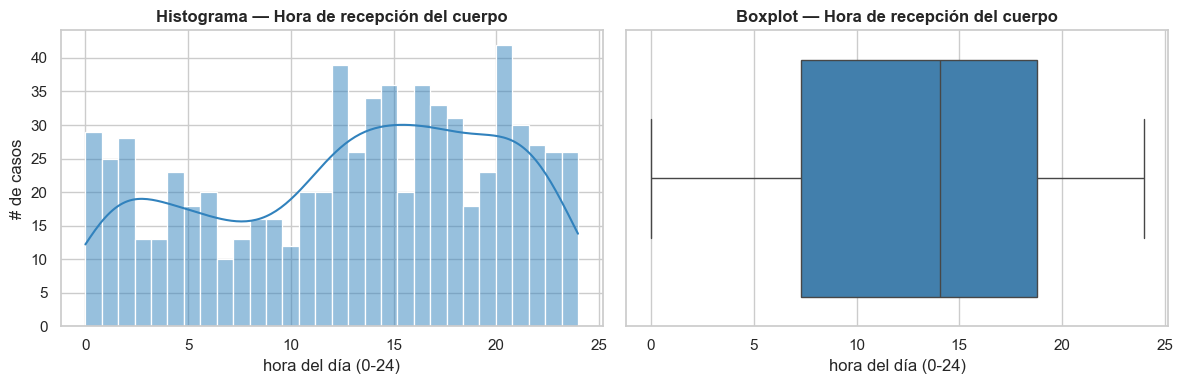

Hora de recepción del cuerpo: n=723 | media=13.08 | mediana=14.05 | desv_std=6.95 | asimetría(skew)=-0.32 | min=0.00 | max=23.97


In [28]:
analizar_numerica(df["hora_recepcion_num"], "Hora de recepción del cuerpo", "hora del día (0-24)")


**Resultados.** Las cuatro variables se comportan de forma muy distinta:

| Variable | n | Mediana | Asimetría | Lectura |
|---|---|---|---|---|
| Edad | 708 | 41.0 años | 0.12 | Prácticamente simétrica; rango de 0.01 a 93 años |
| Días hasta la entrega | 646 | 1 día | 7.32 | Muy asimétrica: 83.3% se entrega en ≤1 día, pero la cola llega a 215 |
| Cronodiagnóstico | 698 | 7 horas | 13.39 | 90.8% de los casos se estima en ≤24 horas |
| Hora de recepción | 723 | 14:03 | −0.32 | Distribución amplia a lo largo del día |

La asimetría de los días hasta la entrega y del cronodiagnóstico no es un defecto de los datos: refleja
que la operación normal del SEMEFO resuelve la mayoría de los casos de inmediato y que los casos lentos
son excepcionales. Esa cola es justamente la población de interés para el proyecto.

La hora de recepción se reparte entre la tarde (32.6%), la noche (29.0%) y la madrugada (21.6%), con la
mañana como franja menos frecuente (16.7%): el servicio opera de forma continua, sin concentración en
horario de oficina.

**Sobre transformaciones.** No se aplican transformaciones logarítmicas ni Box-Cox pese a la asimetría,
por el mismo criterio adoptado en `02_eda_fichas_busqueda.ipynb`: estas variables no alimentan un modelo
de regresión que requiera normalidad, sino ventanas de tolerancia para el filtrado por bloqueo (por
ejemplo, edad ±5 años). Transformar la escala rompería la interpretabilidad de esas ventanas.

### 4.2 Categóricas de baja cardinalidad

17 columnas categóricas de baja cardinalidad (cardinalidad máxima observada: 7)


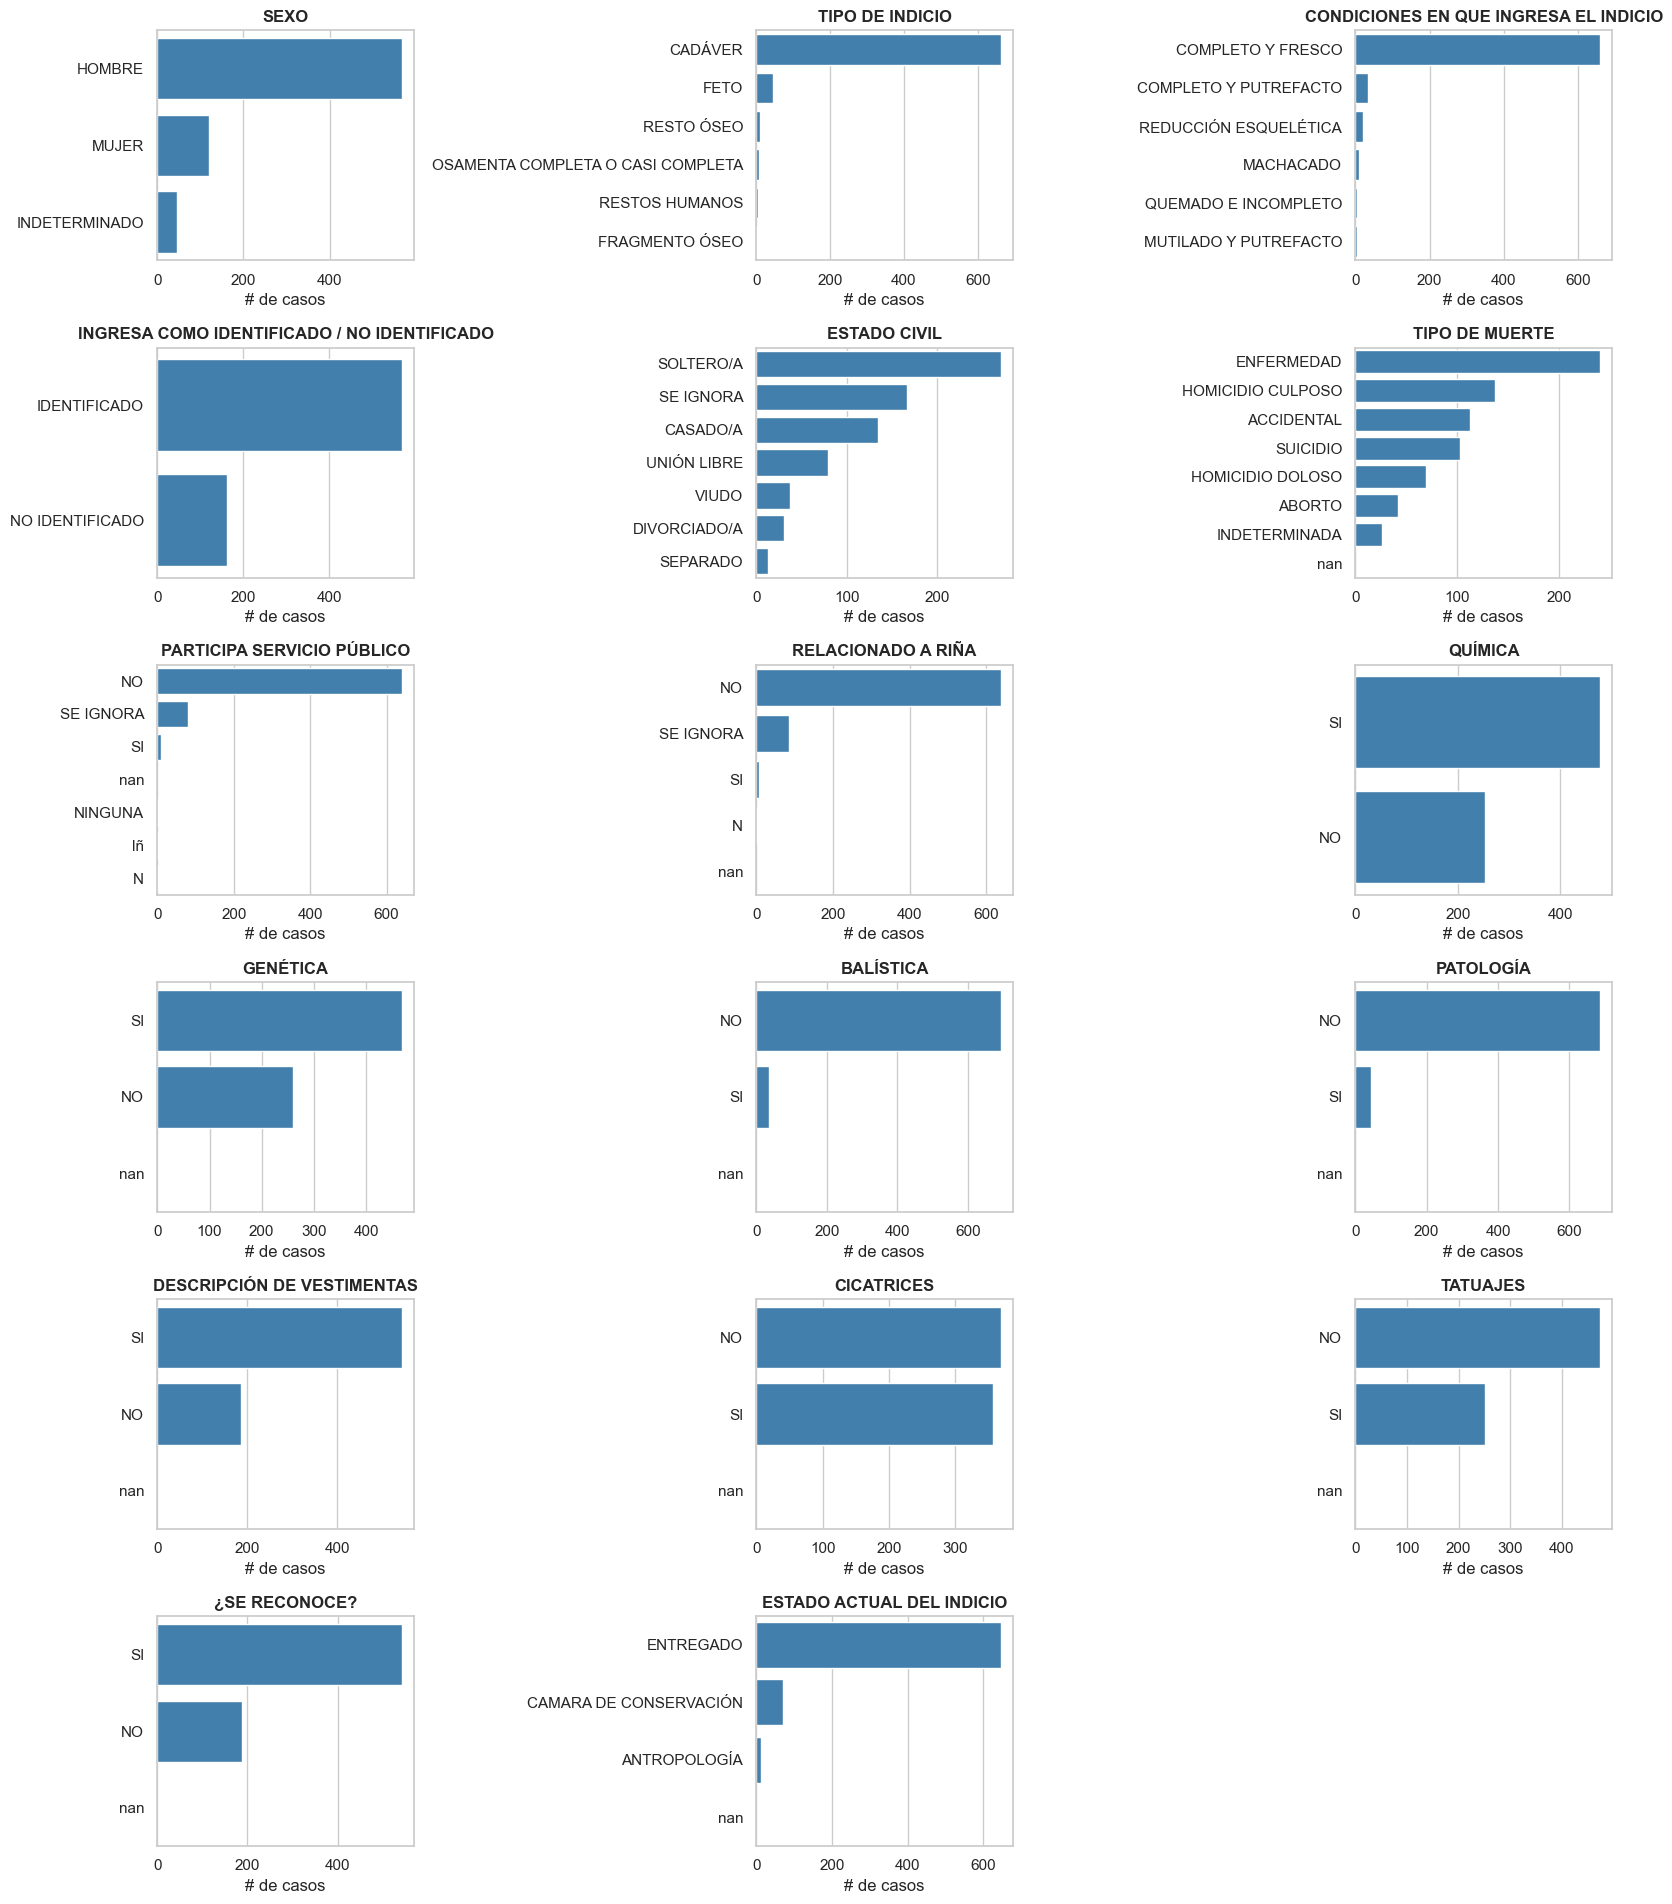

In [29]:
cols_baja_cardinalidad = [
    "SEXO", "TIPO DE INDICIO", "CONDICIONES EN QUE INGRESA EL INDICIO",
    "INGRESA COMO IDENTIFICADO / NO IDENTIFICADO", "ESTADO CIVIL", "TIPO DE MUERTE",
    "PARTICIPA SERVICIO PÚBLICO", "RELACIONADO A RIÑA", "QUÍMICA", "GENÉTICA", "BALÍSTICA",
    "PATOLOGÍA", "DESCRIPCIÓN DE VESTIMENTAS", "CICATRICES", "TATUAJES", "¿SE RECONOCE?",
    "ESTADO ACTUAL DEL INDICIO",
]
print(f"{len(cols_baja_cardinalidad)} columnas categóricas de baja cardinalidad "
      f"(cardinalidad máxima observada: {max(df[c].nunique() for c in cols_baja_cardinalidad)})")

def grid_barras(data, columnas, ncols=3):
    nfilas = int(np.ceil(len(columnas) / ncols))
    fig, axes = plt.subplots(nfilas, ncols, figsize=(ncols * 5.5, nfilas * 3.2))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(columnas):
        ax = axes[i]
        orden = data[col].value_counts(dropna=False).index
        sns.countplot(data=data, y=col, order=orden, ax=ax, color="#3182bd")
        ax.set(title=col[:45], xlabel="# de casos", ylabel="")
    for j in range(len(columnas), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

grid_barras(df, cols_baja_cardinalidad, ncols=3)


**Resultado.** Las variables de baja cardinalidad muestran una población fuertemente concentrada:

- **Sexo**: 567 hombres (77.6%), 119 mujeres (16.3%) y 45 casos indeterminados (6.2%), estos últimos
  asociados a restos óseos y fetos.
- **Tipo de indicio**: 662 cadáveres (90.6%); el resto se reparte entre fetos (44), restos óseos (11),
  osamentas (8), restos humanos (4) y fragmentos óseos (2).
- **Condiciones de ingreso**: 658 casos (90.0%) ingresan completos y frescos.
- **Tipo de muerte**: enfermedad (240) encabeza, seguida de homicidio culposo (137), accidental (113),
  suicidio (103), homicidio doloso (69) y aborto (42).
- **Estatus de identificación**: 568 identificados frente a 163 no identificados.

La concentración es relevante para el diseño del cotejo: las variables de bloqueo con poca variabilidad
—como el tipo de indicio, donde 9 de cada 10 casos caen en una sola categoría— aportan poco poder
discriminante por sí solas.

### 4.3 Categóricas de media y alta cardinalidad

Para las variables con decenas o cientos de categorías se grafican las 15 más frecuentes y se reporta
cuánto representa la cola restante.

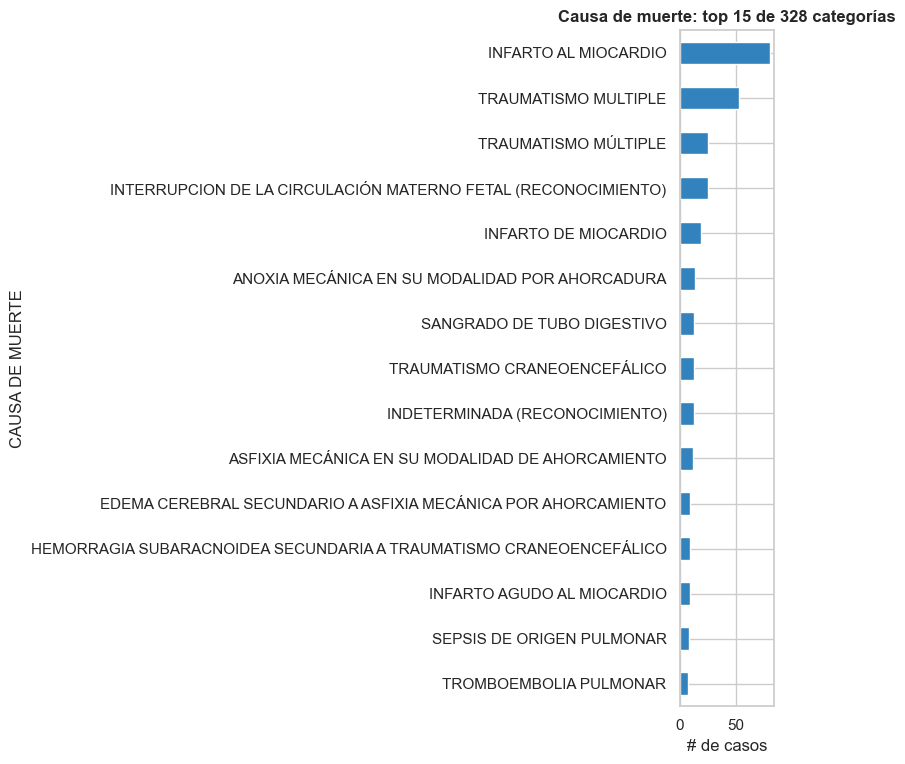

Causa de muerte: 328 categorías en total. Las top 15 cubren 42.4% de los casos no nulos; 313 categorías de cola suman 420 casos.


In [30]:
def top_n_mas_cola(serie, titulo, n=15):
    vc = serie.value_counts(dropna=True)
    top = vc.head(n)
    n_restantes = max(len(vc) - n, 0)
    casos_cola = vc.iloc[n:].sum()
    fig, ax = plt.subplots(figsize=(8, 0.42 * len(top) + 1.5))
    top.sort_values().plot.barh(ax=ax, color="#3182bd")
    ax.set(title=f"{titulo}: top {len(top)} de {len(vc)} categorías", xlabel="# de casos")
    plt.tight_layout()
    plt.show()
    print(f"{titulo}: {len(vc)} categorías en total. Las top {len(top)} cubren "
          f"{100*top.sum()/vc.sum():.1f}% de los casos no nulos; "
          f"{n_restantes} categorías de cola suman {casos_cola} casos.")

top_n_mas_cola(df["CAUSA DE MUERTE"], "Causa de muerte")


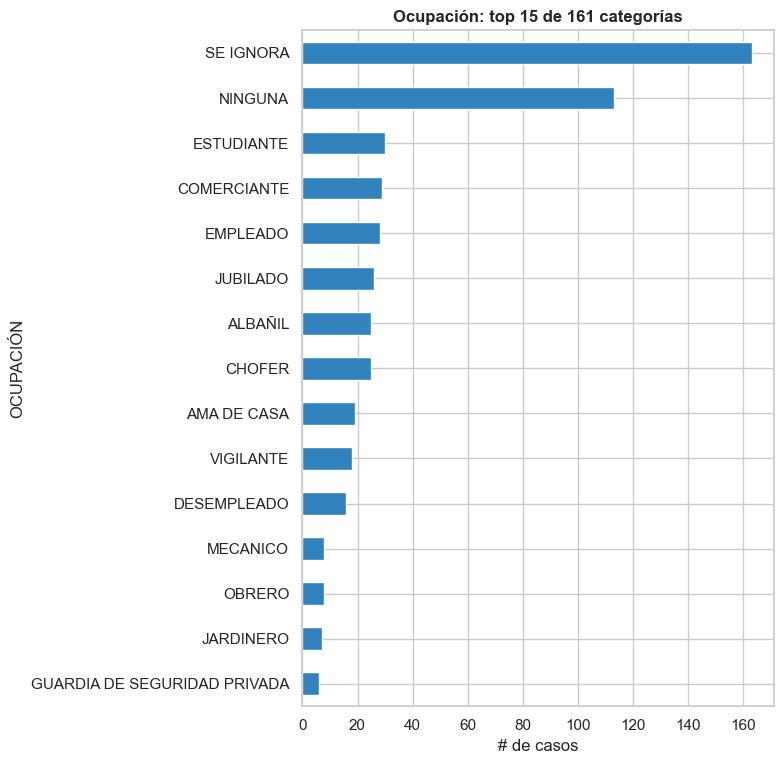

Ocupación: 161 categorías en total. Las top 15 cubren 71.5% de los casos no nulos; 146 categorías de cola suman 208 casos.


In [31]:
top_n_mas_cola(df["OCUPACIÓN"], "Ocupación")


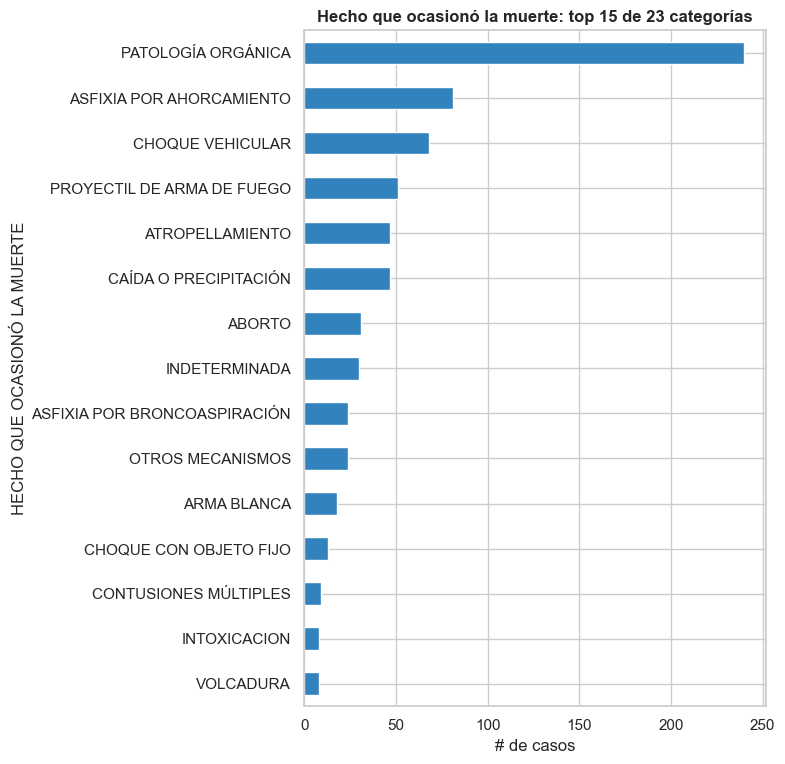

Hecho que ocasionó la muerte: 23 categorías en total. Las top 15 cubren 95.8% de los casos no nulos; 8 categorías de cola suman 31 casos.


In [32]:
top_n_mas_cola(df["HECHO QUE OCASIONÓ LA MUERTE"], "Hecho que ocasionó la muerte")


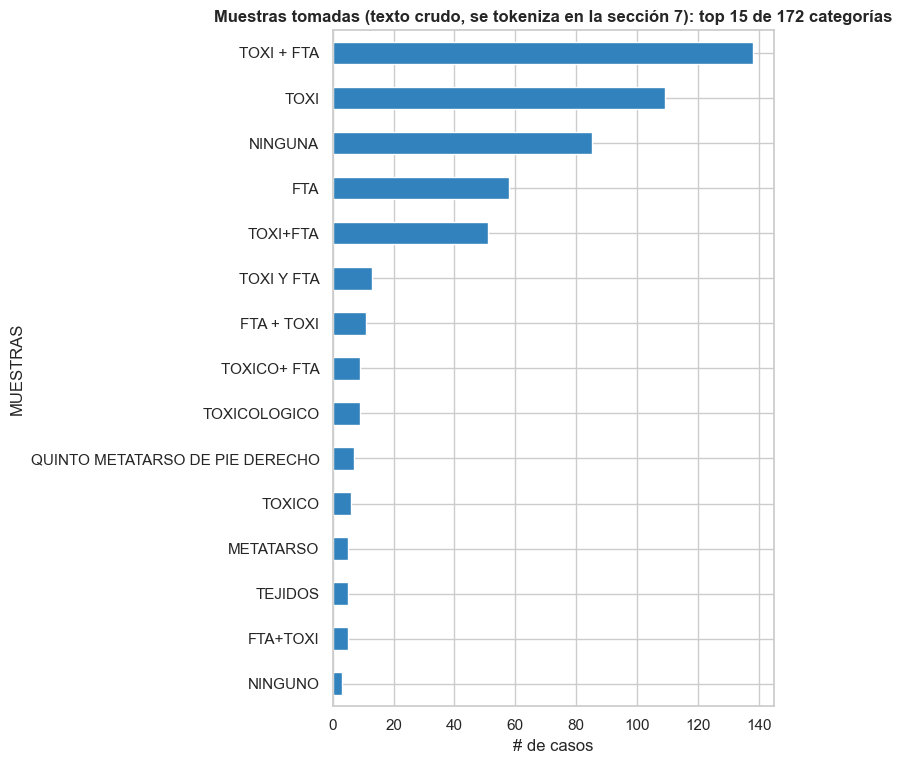

Muestras tomadas (texto crudo, se tokeniza en la sección 7): 172 categorías en total. Las top 15 cubren 73.1% de los casos no nulos; 157 categorías de cola suman 189 casos.


In [33]:
top_n_mas_cola(df["MUESTRAS"], "Muestras tomadas (texto crudo, se tokeniza en la sección 7)")


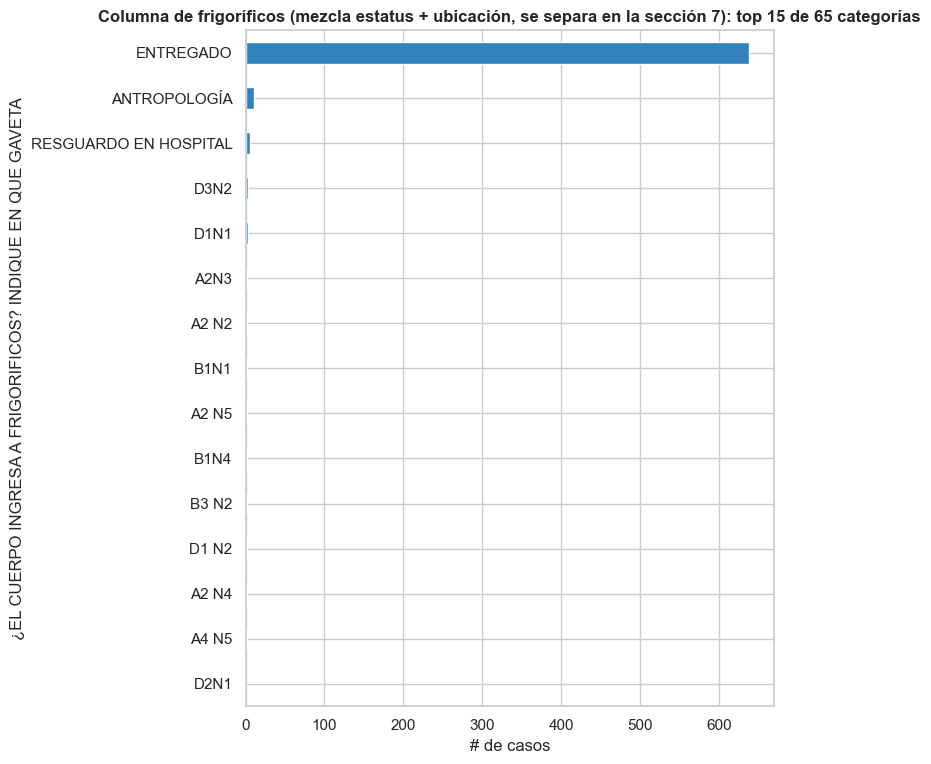

Columna de frigoríficos (mezcla estatus + ubicación, se separa en la sección 7): 65 categorías en total. Las top 15 cubren 93.1% de los casos no nulos; 50 categorías de cola suman 50 casos.


In [34]:
top_n_mas_cola(df["¿EL CUERPO INGRESA A FRIGORIFICOS? INDIQUE EN QUE GAVETA"],
               "Columna de frigoríficos (mezcla estatus + ubicación, se separa en la sección 7)")


**Resultado.** Las cuatro variables de alta cardinalidad tienen comportamientos muy distintos:

| Variable | Categorías | Cobertura del top 15 | Cola |
|---|---|---|---|
| Causa de muerte | 328 | 42.4% | 313 categorías, 420 casos |
| Ocupación | 161 | 71.5% | 146 categorías, 208 casos |
| Hecho que ocasionó la muerte | 23 | 95.8% | 8 categorías, 31 casos |
| Muestras | 172 | 73.1% | 157 categorías, 189 casos |

`HECHO QUE OCASIONÓ LA MUERTE` funciona ya como vocabulario controlado y puede usarse tal cual. En
cambio, la causa de muerte tiene una cola larguísima —casi la mitad de los casos quedan fuera de las 15
categorías más frecuentes— porque se captura como texto semi-libre. Ocupación y muestras requieren
tratamiento distinto: la primera por variantes de escritura, la segunda porque en realidad es una
columna multi-etiqueta donde los códigos se concatenan con `+`. Ambas se procesan en la sección 7.4.

### 4.4 Banderas binarias

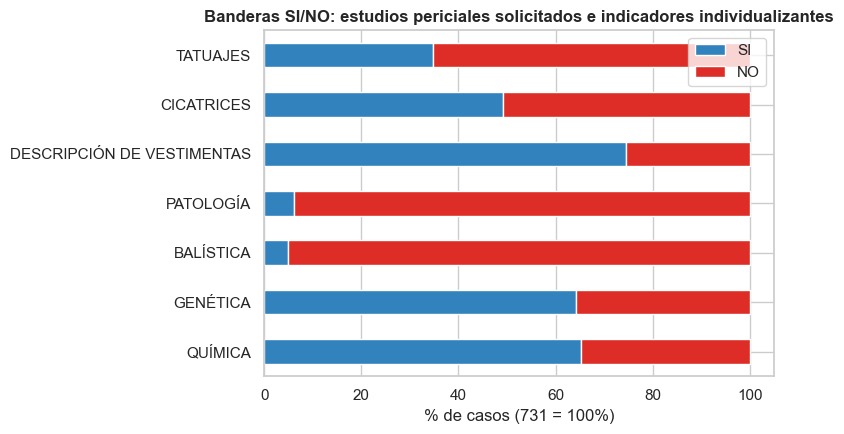

,SI,NO
QUÍMICA,65.3,34.7
GENÉTICA,64.3,35.7
BALÍSTICA,4.9,95.1
PATOLOGÍA,6.0,94.0
DESCRIPCIÓN DE VESTIMENTAS,74.6,25.4
CICATRICES,49.2,50.8
TATUAJES,34.7,65.3


In [35]:
cols_bandera_estudios = ["QUÍMICA", "GENÉTICA", "BALÍSTICA", "PATOLOGÍA"]
cols_bandera_individualizantes = ["DESCRIPCIÓN DE VESTIMENTAS", "CICATRICES", "TATUAJES"]
cols_bandera = cols_bandera_estudios + cols_bandera_individualizantes

tabla_banderas = pd.DataFrame({
    c: df[c].value_counts(normalize=True).reindex(["SI", "NO"]) * 100 for c in cols_bandera
}).T

fig, ax = plt.subplots(figsize=(8, 4.5))
tabla_banderas.plot(kind="barh", stacked=True, ax=ax, color=["#3182bd", "#de2d26"])
ax.set(title="Banderas SI/NO: estudios periciales solicitados e indicadores individualizantes",
       xlabel="% de casos (731 = 100%)")
ax.legend(title="")
plt.tight_layout()
plt.show()
tabla_banderas.round(1)


**Hallazgo relevante para el cotejo.** `DESCRIPCIÓN DE VESTIMENTAS` y `CICATRICES` contienen únicamente
`SI`/`NO`: señalan que la información existe en el dictamen original, pero no la contienen. Solo
`TATUAJES` tiene asociada una columna con descripción textual, que se analiza en 4.5.

Los estudios de laboratorio muestran dos patrones distintos: química (65.3%) y genética (64.3%) se
solicitan de forma rutinaria, mientras que balística (4.9%) y patología (6.0%) son excepcionales y
responden al tipo de caso.

### 4.5 Texto libre

De las columnas de texto libre solo se reportan longitud y cobertura, nunca el contenido.

Literales tratados como relleno/no-aplica en DESCRIPCIÓN TATUAJES ({'NINGUNO', 'NA', 'N/A', 'NO APLICA'}):
DESCRIPCIÓN TATUAJES
NAN          512
NO APLICA     12
NINGUNO        6

DESCRIPCIÓN TATUAJES con contenido individualizante sustantivo: 201/731 = 27.5% de los 731 casos.
(Este es el ÚNICO campo de texto libre verdaderamente individualizante del libro.)


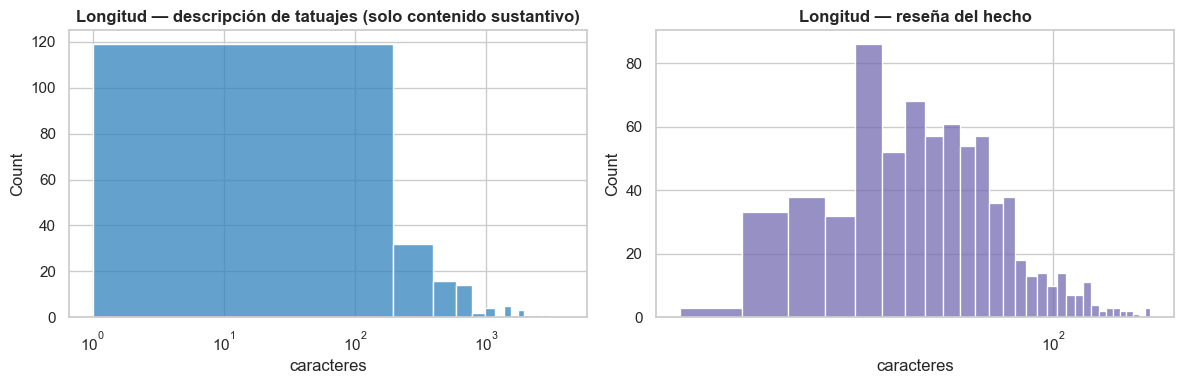

In [36]:
LITERALES_NO_APLICA_TATUAJES = {"N/A", "NA", "NO APLICA", "NINGUNO"}

desc_tat_mayus = df["DESCRIPCIÓN TATUAJES"].astype(str).str.strip().str.upper()
es_relleno = df["DESCRIPCIÓN TATUAJES"].isna() | desc_tat_mayus.isin(LITERALES_NO_APLICA_TATUAJES)
n_sustantivo = int((~es_relleno).sum())
pct_sustantivo = 100 * n_sustantivo / len(df)

print("Literales tratados como relleno/no-aplica en DESCRIPCIÓN TATUAJES "
      f"({LITERALES_NO_APLICA_TATUAJES}):")
print(desc_tat_mayus[es_relleno].value_counts().to_string())
print(f"\nDESCRIPCIÓN TATUAJES con contenido individualizante sustantivo: "
      f"{n_sustantivo}/{len(df)} = {pct_sustantivo:.1f}% de los 731 casos.")
print("(Este es el ÚNICO campo de texto libre verdaderamente individualizante del libro.)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.loc[~es_relleno, "desc_tatuajes_longitud"], bins=20, ax=axes[0], color="#3182bd")
axes[0].set(title="Longitud — descripción de tatuajes (solo contenido sustantivo)",
            xlabel="caracteres", xscale="log")
sns.histplot(df["resena_longitud"].dropna(), bins=30, ax=axes[1], color="#756bb1")
axes[1].set(title="Longitud — reseña del hecho", xlabel="caracteres", xscale="log")
plt.tight_layout()
plt.show()


**Resultado.** Las tres columnas de texto libre tienen coberturas muy desiguales:

| Columna | Cobertura | Longitud mediana | Longitud máxima |
|---|---|---|---|
| Reseña del hecho | 99.7% | 54 caracteres | 170 |
| Lugar donde ocurrió el hecho | 99.9% | 56 caracteres | 152 |
| Descripción de tatuajes | 30.0% bruta → **27.5% sustantiva** | 124 caracteres | 3,956 |

La descripción de tatuajes es la única columna con contenido individualizante, y su cobertura efectiva es
de 201 de 731 casos: el 70% de las celdas no vacías son literales de relleno (`N/A`, `NO APLICA`,
`NINGUNO`). Su longitud es además muy dispersa, de 5 a 3,956 caracteres, lo que indica criterios de
captura heterogéneos entre peritos.

Esto acota el alcance del cotejo: **en menos de un tercio de los casos existe una descripción textual
que un sistema de similitud pueda comparar contra la ficha de búsqueda.**

## 5. Análisis bivariante y multivariante

El libro tiene 4 variables numéricas y alrededor de 18 categóricas. Una matriz de correlación de Pearson
sobre las numéricas dejaría fuera la mayor parte de la estructura de los datos, por lo que se emplean
tres medidas de asociación según el tipo de par, todas acompañadas de su representación gráfica:

| Medida | Tipo de par | Observaciones |
|---|---|---|
| **Cramér's V** | categórica–categórica | Con corrección de sesgo de Bergsma; se reporta χ² y p-valor |
| **Razón de correlación η²** | numérica–categórica | Proporción de varianza de la numérica explicada por la categórica |
| **Spearman** | numérica–numérica | No asume linealidad |

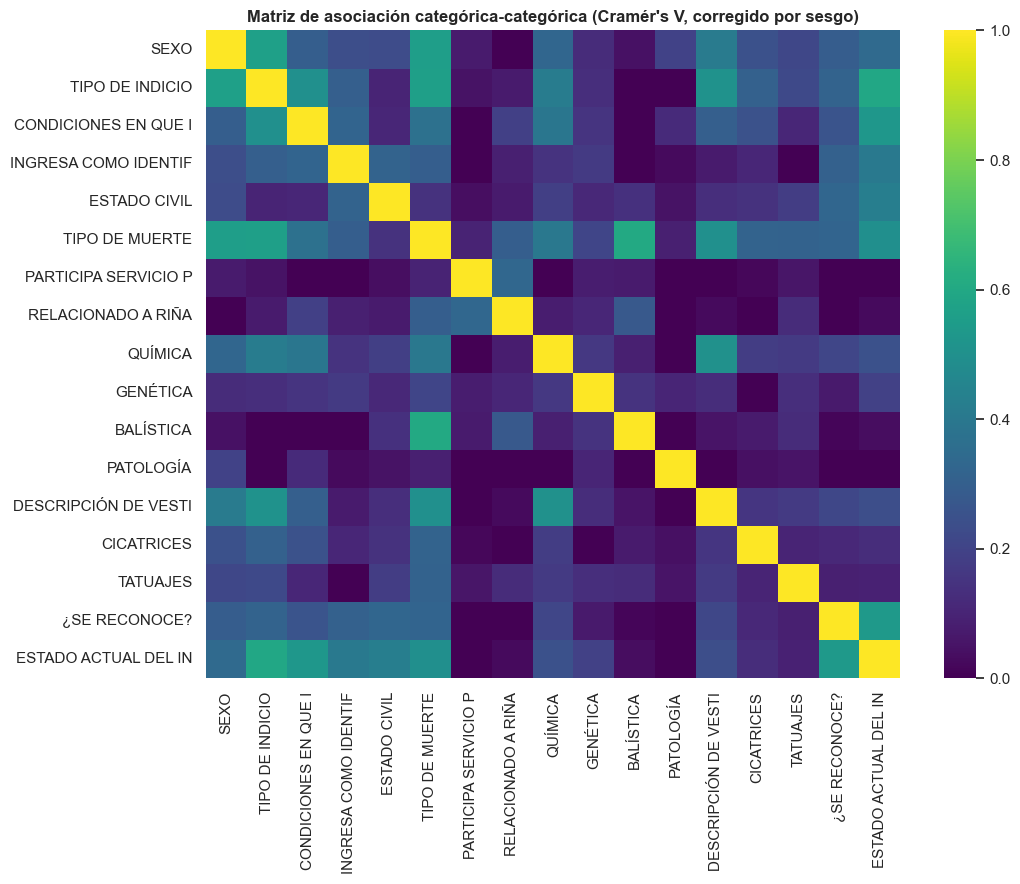

In [37]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    if tabla.shape[0] < 2 or tabla.shape[1] < 2:
        return np.nan, np.nan
    chi2, p, dof, _ = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    phi2_corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    v = np.sqrt(phi2_corr / denom) if denom > 0 else np.nan
    return v, p

cols_cramer = cols_baja_cardinalidad  # las 17 categóricas de baja cardinalidad de la sección 4.2
n_c = len(cols_cramer)
matriz_v = pd.DataFrame(np.eye(n_c), index=cols_cramer, columns=cols_cramer)
matriz_p = pd.DataFrame(np.nan, index=cols_cramer, columns=cols_cramer)
for i in range(n_c):
    for j in range(i + 1, n_c):
        v, p = cramers_v(df[cols_cramer[i]], df[cols_cramer[j]])
        matriz_v.iloc[i, j] = matriz_v.iloc[j, i] = v
        matriz_p.iloc[i, j] = matriz_p.iloc[j, i] = p

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(matriz_v, cmap="viridis", vmin=0, vmax=1, annot=False, ax=ax,
            xticklabels=[c[:20] for c in cols_cramer], yticklabels=[c[:20] for c in cols_cramer])
ax.set_title("Matriz de asociación categórica-categórica (Cramér's V, corregido por sesgo)")
plt.tight_layout()
plt.show()


In [38]:
# Pares principales con su chi2 y p-valor explícitos
pares_principales = [
    ("INGRESA COMO IDENTIFICADO / NO IDENTIFICADO", "TIPO DE INDICIO"),
    ("INGRESA COMO IDENTIFICADO / NO IDENTIFICADO", "CONDICIONES EN QUE INGRESA EL INDICIO"),
    ("INGRESA COMO IDENTIFICADO / NO IDENTIFICADO", "SEXO"),
    ("INGRESA COMO IDENTIFICADO / NO IDENTIFICADO", "TATUAJES"),
    ("¿SE RECONOCE?", "TIPO DE INDICIO"),
    ("TIPO DE MUERTE", "SEXO"),
]
filas = []
for a, b in pares_principales:
    v, p = cramers_v(df[a], df[b])
    chi2, p2, dof, _ = stats.chi2_contingency(pd.crosstab(df[a], df[b]))
    filas.append({"var_a": a, "var_b": b, "cramers_v": round(v, 3), "chi2": round(chi2, 1),
                   "dof": dof, "p_valor": "<0.001" if p2 < 0.001 else round(p2, 4)})
pd.DataFrame(filas)


,var_a,var_b,cramers_v,chi2,dof,p_valor
0,INGRESA COMO IDENTIFICADO / NO IDENTIFICADO,TIPO DE INDICIO,0.298,69.8,5,<0.001
1,INGRESA COMO IDENTIFICADO / NO IDENTIFICADO,CONDICIONES EN QUE INGRESA EL INDICIO,0.318,78.8,5,<0.001
2,INGRESA COMO IDENTIFICADO / NO IDENTIFICADO,SEXO,0.236,42.7,2,<0.001
3,INGRESA COMO IDENTIFICADO / NO IDENTIFICADO,TATUAJES,0.000,0.1,1,0.7109
4,¿SE RECONOCE?,TIPO DE INDICIO,0.315,77.4,5,<0.001
5,TIPO DE MUERTE,SEXO,0.558,465.5,12,<0.001


**Resultado.** La matriz de asociación muestra que el estatus de identificación se relaciona de forma
significativa con el estado físico del cuerpo, pero no con la presencia de tatuajes:

| Par de variables | Cramér's V | p-valor |
|---|---|---|
| Identificación × Condiciones de ingreso | 0.318 | < 0.001 |
| Identificación × Tipo de indicio | 0.298 | < 0.001 |
| Identificación × Sexo | 0.236 | < 0.001 |
| Identificación × Tatuajes | 0.000 | 0.711 |
| Tipo de muerte × Sexo | 0.558 | < 0.001 |

La asociación más fuerte del libro es entre tipo de muerte y sexo (V = 0.558), consistente con la
sobrerrepresentación masculina en muertes violentas.

El resultado con mayor consecuencia para el proyecto es el de tatuajes: **V = 0.000, p = 0.711**. La
presencia de tatuajes es estadísticamente independiente del estatus de identificación, es decir, los
cuerpos no identificados no tienen más ni menos tatuajes que los identificados. Esto es una buena
noticia: el único campo individualizante disponible no está sesgado en contra de la población que
necesita el cotejo.

### 5.1 Razón de correlación η²

In [39]:
def eta_cuadrado(num, cat):
    tmp = pd.DataFrame({"num": num, "cat": cat}).dropna()
    if tmp["cat"].nunique() < 2:
        return np.nan
    media_global = tmp["num"].mean()
    ss_total = ((tmp["num"] - media_global) ** 2).sum()
    ss_entre = sum(
        len(g) * (g["num"].mean() - media_global) ** 2 for _, g in tmp.groupby("cat")
    )
    return ss_entre / ss_total if ss_total > 0 else np.nan

pares_eta = [
    ("edad_anios", "TIPO DE MUERTE"), ("edad_anios", "SEXO"),
    ("edad_anios", "INGRESA COMO IDENTIFICADO / NO IDENTIFICADO"),
    ("dias_entrega", "ESTADO ACTUAL DEL INDICIO"),
    ("dias_entrega", "CONDICIONES EN QUE INGRESA EL INDICIO"),
    ("horas_crono", "TIPO DE MUERTE"),
]
tabla_eta = pd.DataFrame([
    {"numerica": num, "categorica": cat, "eta_cuadrado": round(eta_cuadrado(df[num], df[cat]), 3)}
    for num, cat in pares_eta
]).sort_values("eta_cuadrado", ascending=False)
tabla_eta


,numerica,categorica,eta_cuadrado
0,edad_anios,TIPO DE MUERTE,0.262
4,dias_entrega,CONDICIONES EN QUE INGRESA EL INDICIO,0.086
1,edad_anios,SEXO,0.062
5,horas_crono,TIPO DE MUERTE,0.031
2,edad_anios,INGRESA COMO IDENTIFICADO / NO IDENTIFICADO,0.000
3,dias_entrega,ESTADO ACTUAL DEL INDICIO,NaN


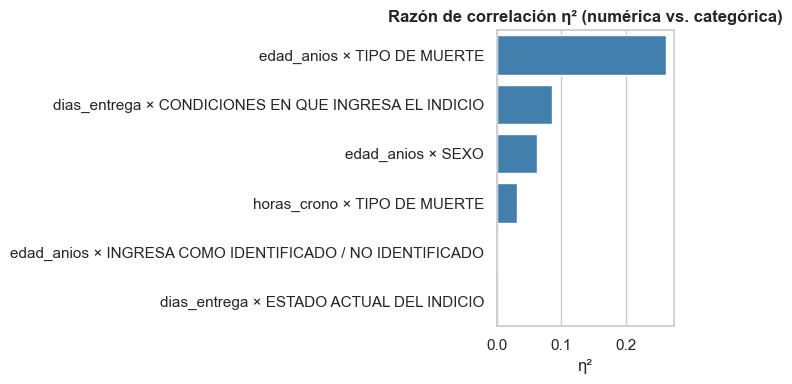

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=tabla_eta, y=[f"{n} × {c}" for n, c in zip(tabla_eta.numerica, tabla_eta.categorica)],
            x="eta_cuadrado", ax=ax, color="#3182bd")
ax.set(title="Razón de correlación η² (numérica vs. categórica)", xlabel="η²", ylabel="")
plt.tight_layout()
plt.show()


**Resultado.** Las asociaciones numérica–categórica son en general débiles, con una excepción:

| Par | η² | Lectura |
|---|---|---|
| Edad × Tipo de muerte | 0.262 | El tipo de muerte explica el 26% de la varianza de la edad |
| Días de entrega × Condiciones de ingreso | 0.086 | Asociación débil |
| Edad × Sexo | 0.062 | Asociación débil |
| Edad × Estatus de identificación | 0.000 | Sin relación |

Que la edad no guarde relación alguna con el estatus de identificación (η² = 0.000) tiene la misma
implicación práctica que el resultado de tatuajes: la población no identificada no se concentra en ningún
rango de edad, por lo que la edad sirve como criterio de bloqueo sin introducir sesgo.

### 5.2 Correlación de Spearman entre numéricas

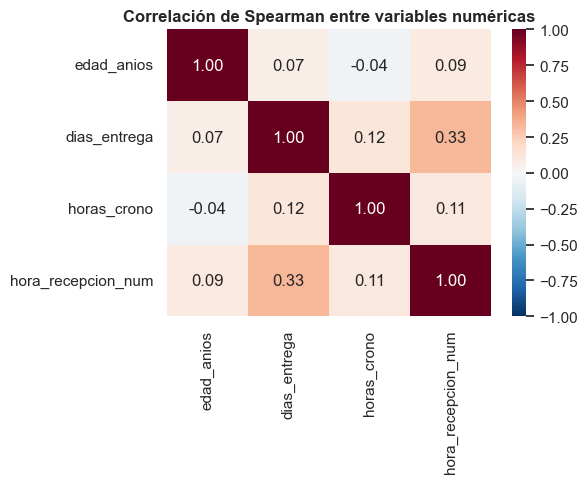

,edad_anios,dias_entrega,horas_crono,hora_recepcion_num
edad_anios,1.000000,0.069784,-0.042933,0.090236
dias_entrega,0.069784,1.000000,0.123065,0.334021
horas_crono,-0.042933,0.123065,1.000000,0.106724
hora_recepcion_num,0.090236,0.334021,0.106724,1.000000


In [41]:
cols_numericas = ["edad_anios", "dias_entrega", "horas_crono", "hora_recepcion_num"]
corr_spearman = df[cols_numericas].corr(method="spearman")
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de Spearman entre variables numéricas")
plt.tight_layout()
plt.show()
corr_spearman


**Resultado.** Las correlaciones entre variables numéricas son bajas. La única apreciable es entre la
hora de recepción y los días hasta la entrega (ρ = 0.33): los cuerpos que ingresan más tarde en el día
tardan más en ser entregados, lo cual refleja la operación por turnos más que una propiedad del caso. La
edad es prácticamente independiente de las tres restantes (|ρ| ≤ 0.09).

### 5.3 Composición por estatus de identificación

Se compara la composición de los cuerpos identificados y no identificados frente a las variables que
podrían servir como criterio de bloqueo en el cotejo.

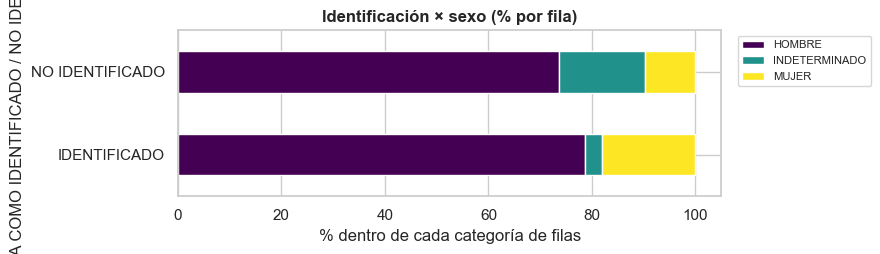

SEXO,HOMBRE,INDETERMINADO,MUJER
INGRESA COMO IDENTIFICADO / NO IDENTIFICADO,,,
IDENTIFICADO,78.7,3.2,18.1
NO IDENTIFICADO,73.6,16.6,9.8


In [42]:
def crosstab_100(data, filas_col, columnas_col, titulo, top_n_columnas=None):
    tabla = pd.crosstab(data[filas_col], data[columnas_col])
    if top_n_columnas is not None and tabla.shape[1] > top_n_columnas:
        top_cols = tabla.sum().sort_values(ascending=False).head(top_n_columnas).index
        tabla = tabla[top_cols]
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
    fig, ax = plt.subplots(figsize=(9, 0.6 * tabla_pct.shape[0] + 1.5))
    tabla_pct.plot(kind="barh", stacked=True, ax=ax, colormap="viridis")
    ax.set(title=titulo, xlabel="% dentro de cada categoría de filas")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
    return tabla_pct.round(1)

crosstab_100(df, "INGRESA COMO IDENTIFICADO / NO IDENTIFICADO", "SEXO",
             "Identificación × sexo (% por fila)")


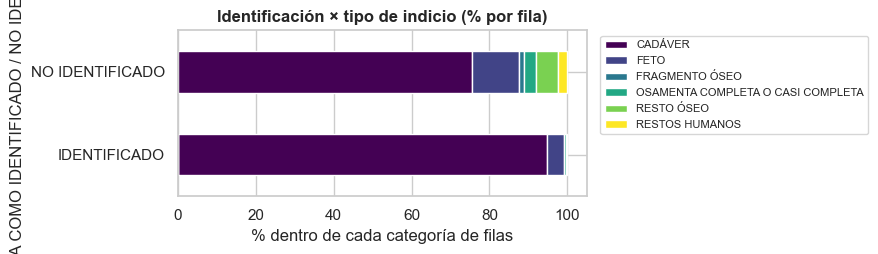

TIPO DE INDICIO,CADÁVER,FETO,FRAGMENTO ÓSEO,OSAMENTA COMPLETA O CASI COMPLETA,RESTO ÓSEO,RESTOS HUMANOS
INGRESA COMO IDENTIFICADO / NO IDENTIFICADO,,,,,,
IDENTIFICADO,94.9,4.2,0.0,0.5,0.4,0.0
NO IDENTIFICADO,75.5,12.3,1.2,3.1,5.5,2.5


In [43]:
crosstab_100(df, "INGRESA COMO IDENTIFICADO / NO IDENTIFICADO", "TIPO DE INDICIO",
             "Identificación × tipo de indicio (% por fila)")


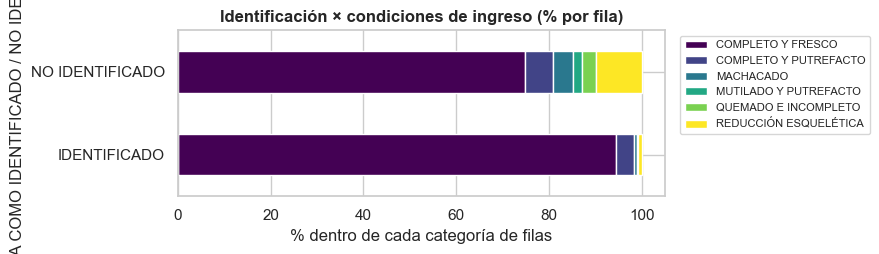

CONDICIONES EN QUE INGRESA EL INDICIO,COMPLETO Y FRESCO,COMPLETO Y PUTREFACTO,MACHACADO,MUTILADO Y PUTREFACTO,QUEMADO E INCOMPLETO,REDUCCIÓN ESQUELÉTICA
INGRESA COMO IDENTIFICADO / NO IDENTIFICADO,,,,,,
IDENTIFICADO,94.4,4.0,0.5,0.2,0.0,0.9
NO IDENTIFICADO,74.8,6.1,4.3,1.8,3.1,9.8


In [44]:
crosstab_100(df, "INGRESA COMO IDENTIFICADO / NO IDENTIFICADO", "CONDICIONES EN QUE INGRESA EL INDICIO",
             "Identificación × condiciones de ingreso (% por fila)")


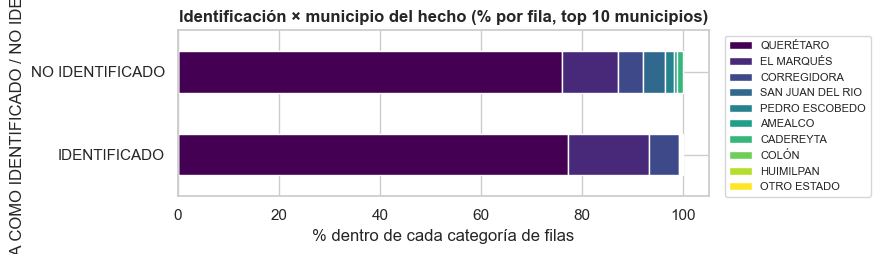

MUNICIPIO DONDE OCURRIÓ EL HECHO,QUERÉTARO,EL MARQUÉS,CORREGIDORA,SAN JUAN DEL RIO,PEDRO ESCOBEDO,AMEALCO,CADEREYTA,COLÓN,HUIMILPAN,OTRO ESTADO
INGRESA COMO IDENTIFICADO / NO IDENTIFICADO,,,,,,,,,,
IDENTIFICADO,77.1,16.0,6.0,0.0,0.2,0.2,0.0,0.2,0.2,0.2
NO IDENTIFICADO,75.9,11.1,4.9,4.3,1.9,0.6,1.2,0.0,0.0,0.0


In [45]:
crosstab_100(df, "INGRESA COMO IDENTIFICADO / NO IDENTIFICADO", "MUNICIPIO DONDE OCURRIÓ EL HECHO",
             "Identificación × municipio del hecho (% por fila, top 10 municipios)", top_n_columnas=10)


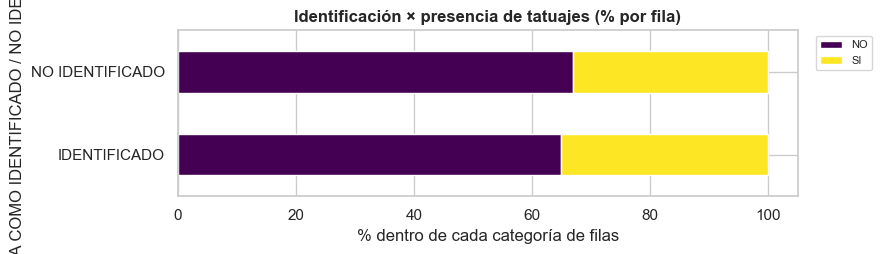

TATUAJES,NO,SI
INGRESA COMO IDENTIFICADO / NO IDENTIFICADO,,
IDENTIFICADO,64.9,35.1
NO IDENTIFICADO,66.9,33.1


In [46]:
crosstab_100(df, "INGRESA COMO IDENTIFICADO / NO IDENTIFICADO", "TATUAJES",
             "Identificación × presencia de tatuajes (% por fila)")


**Resultado.** La composición difiere de forma marcada entre ambos grupos:

- **Sexo**: entre los no identificados, el 16.6% son casos de sexo indeterminado, frente al 3.2% entre
  los identificados. Visto como tasa, el 60.0% de los casos de sexo indeterminado no se identifica,
  contra 21.2% en hombres y 13.4% en mujeres.
- **Tipo de indicio**: el 94.9% de los identificados son cadáveres completos; entre los no identificados
  esa proporción baja al 75.5%, y aparecen restos óseos (5.5%), osamentas (3.1%) y fragmentos.
- **Condiciones de ingreso**: la reducción esquelética representa el 9.8% de los no identificados frente
  al 0.9% de los identificados.
- **Municipio**: la distribución es similar en los tres municipios principales, pero los casos de
  San Juan del Río (7) no se identificaron en ningún caso. Con esos tamaños de muestra la diferencia no
  es concluyente.
- **Tatuajes**: 35.1% frente a 33.1%, prácticamente idéntica, en línea con el Cramér's V de la sección 5.

El patrón es consistente: **lo que predice la no identificación es el estado físico del cuerpo**, no sus
características demográficas ni el lugar del hecho.

### 5.4 Poblaciones objetivo del cotejo

`INGRESA COMO IDENTIFICADO / NO IDENTIFICADO` registra cómo llegó el cuerpo; `¿SE RECONOCE?` registra si
posteriormente se logró el reconocimiento. El cruce de ambas delimita las poblaciones que importan
operativamente al proyecto.

In [47]:
tabla_2x2 = pd.crosstab(df["INGRESA COMO IDENTIFICADO / NO IDENTIFICADO"], df["¿SE RECONOCE?"],
                        margins=True, margins_name="Total")
print(tabla_2x2)

n_objetivo = tabla_2x2.loc["NO IDENTIFICADO", "NO"] if "NO" in tabla_2x2.columns else np.nan
n_gold = tabla_2x2.loc["NO IDENTIFICADO", "SI"] if "SI" in tabla_2x2.columns else np.nan
print(f"\nn = {n_objetivo} -> cuerpos que ingresaron NO IDENTIFICADOS y NO se reconocieron: "
      f"universo objetivo real del cotejo contra fichas de búsqueda.")
print(f"n = {n_gold} -> cuerpos que ingresaron NO IDENTIFICADOS y SÍ se reconocieron después: "
      f"gold standard para medir recall@k del sistema de recuperación sin etiquetado manual nuevo.")


¿SE RECONOCE?                                 NO   SI  Total
INGRESA COMO IDENTIFICADO / NO IDENTIFICADO                 
IDENTIFICADO                                 104  462    566
NO IDENTIFICADO                               83   80    163
Total                                        187  542    729

n = 83 -> cuerpos que ingresaron NO IDENTIFICADOS y NO se reconocieron: universo objetivo real del cotejo contra fichas de búsqueda.
n = 80 -> cuerpos que ingresaron NO IDENTIFICADOS y SÍ se reconocieron después: gold standard para medir recall@k del sistema de recuperación sin etiquetado manual nuevo.


**Resultado.** El cruce delimita cuatro grupos, de los cuales dos son los relevantes:

|  | Se reconoce = NO | Se reconoce = SÍ | Total |
|---|---|---|---|
| **Identificado** | 104 | 462 | 566 |
| **No identificado** | **83** | **80** | 163 |

- **n = 83** — cuerpos que ingresaron sin identificar y que siguen sin reconocerse. Es el universo real
  sobre el que operaría el sistema de cotejo contra las fichas de búsqueda.
- **n = 80** — cuerpos que ingresaron sin identificar y que sí se reconocieron después. Estos casos
  permiten medir *recall@k* del sistema de recuperación usando emparejamientos ya verificados, sin
  necesidad de etiquetado manual adicional por parte de la Fiscalía.

Los 104 casos identificados que no registran reconocimiento corresponden probablemente a
identificaciones administrativas sin reconocimiento formal de un familiar.

### 5.5 Edad según tipo de muerte y estatus de identificación

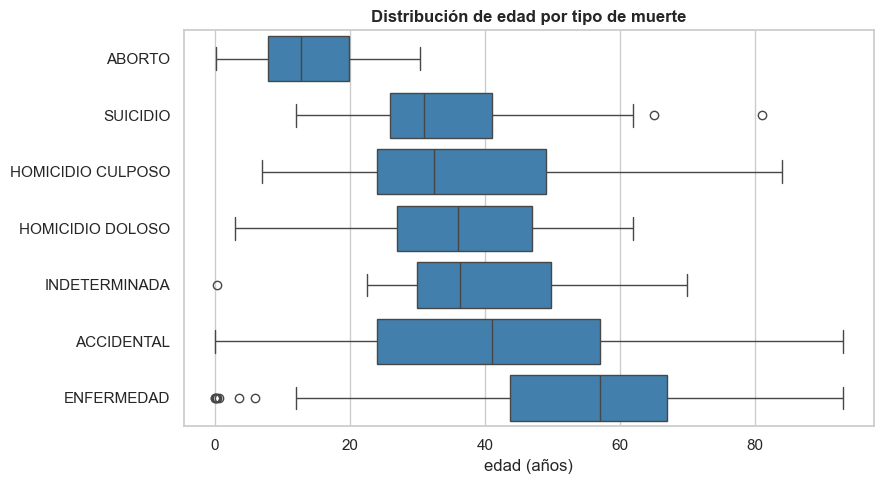

In [48]:
orden_tipo_muerte = df.groupby("TIPO DE MUERTE")["edad_anios"].median().sort_values().index
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="edad_anios", y="TIPO DE MUERTE", order=orden_tipo_muerte, ax=ax, color="#3182bd")
ax.set(title="Distribución de edad por tipo de muerte", xlabel="edad (años)", ylabel="")
plt.tight_layout()
plt.show()


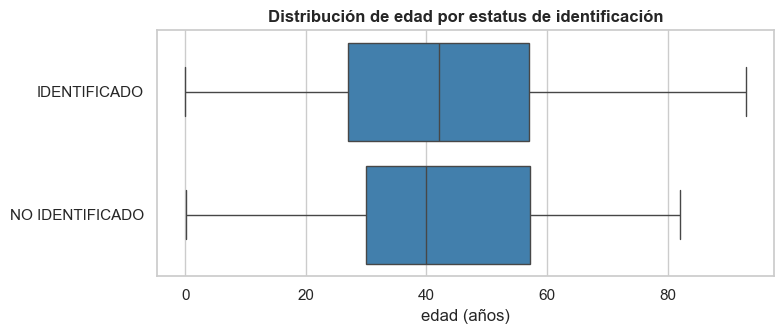

In [49]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.boxplot(data=df, x="edad_anios", y="INGRESA COMO IDENTIFICADO / NO IDENTIFICADO", ax=ax, color="#3182bd")
ax.set(title="Distribución de edad por estatus de identificación", xlabel="edad (años)", ylabel="")
plt.tight_layout()
plt.show()


**Resultado.** La edad discrimina claramente entre tipos de muerte: la mediana va de 12.8 años en aborto
y 31.0 en suicidio, a 41.0 en muerte accidental y 57.0 en enfermedad. El gradiente es coherente con el
perfil epidemiológico esperado y explica el η² de 0.262 de la sección 5.1.

En cambio, la edad **no** distingue entre identificados y no identificados: mediana de 42.0 frente a 40.0
años, con medias casi idénticas (42.2 y 42.4). La dificultad de identificación no está asociada a la edad
de la persona.

### 5.6 Tasa de no identificación por tipo y condición del indicio

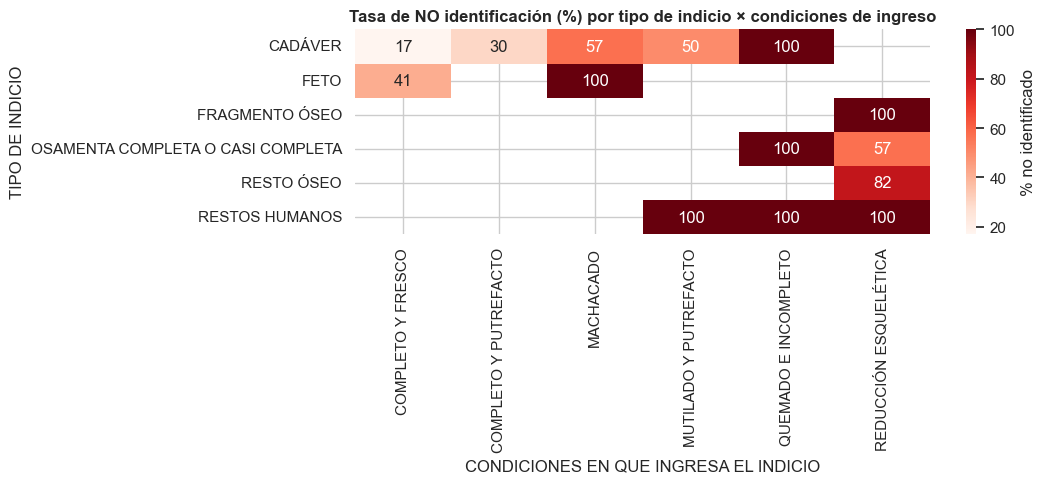

Tamaño de muestra (n) por celda (celdas con n pequeño deben leerse con cautela):


CONDICIONES EN QUE INGRESA EL INDICIO,COMPLETO Y FRESCO,COMPLETO Y PUTREFACTO,MACHACADO,MUTILADO Y PUTREFACTO,QUEMADO E INCOMPLETO,REDUCCIÓN ESQUELÉTICA
TIPO DE INDICIO,,,,,,
CADÁVER,617.0,33.0,7.0,2.0,3.0,NaN
FETO,41.0,NaN,3.0,NaN,NaN,NaN
FRAGMENTO ÓSEO,NaN,NaN,NaN,NaN,NaN,2.0
OSAMENTA COMPLETA O CASI COMPLETA,NaN,NaN,NaN,NaN,1.0,7.0
RESTO ÓSEO,NaN,NaN,NaN,NaN,NaN,11.0
RESTOS HUMANOS,NaN,NaN,NaN,2.0,1.0,1.0


In [50]:
df["no_identificado_flag"] = (df["INGRESA COMO IDENTIFICADO / NO IDENTIFICADO"] == "NO IDENTIFICADO").astype(int)
tabla_tasa_noident = df.pivot_table(
    index="TIPO DE INDICIO", columns="CONDICIONES EN QUE INGRESA EL INDICIO",
    values="no_identificado_flag", aggfunc="mean",
) * 100
tabla_n = df.pivot_table(
    index="TIPO DE INDICIO", columns="CONDICIONES EN QUE INGRESA EL INDICIO",
    values="no_identificado_flag", aggfunc="count",
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(tabla_tasa_noident, annot=True, fmt=".0f", cmap="Reds", ax=ax, cbar_kws={"label": "% no identificado"})
ax.set_title("Tasa de NO identificación (%) por tipo de indicio × condiciones de ingreso")
plt.tight_layout()
plt.show()

print("Tamaño de muestra (n) por celda (celdas con n pequeño deben leerse con cautela):")
tabla_n


In [51]:
tasa_por_tipo_indicio = df.groupby("TIPO DE INDICIO")["no_identificado_flag"].mean().sort_values(ascending=False) * 100
print("Tasa de NO identificación por TIPO DE INDICIO (marginal, ordenado):")
print(tasa_por_tipo_indicio.round(1).to_string())


Tasa de NO identificación por TIPO DE INDICIO (marginal, ordenado):
TIPO DE INDICIO
FRAGMENTO ÓSEO                       100.0
RESTOS HUMANOS                       100.0
RESTO ÓSEO                            81.8
OSAMENTA COMPLETA O CASI COMPLETA     62.5
FETO                                  45.5
CADÁVER                               18.6


**Resultado.** La tasa de no identificación sigue un gradiente estricto según el grado de conservación
del cuerpo:

| Tipo de indicio | Tasa de no identificación | n |
|---|---|---|
| Fragmento óseo | 100.0% | 2 |
| Restos humanos | 100.0% | 4 |
| Resto óseo | 81.8% | 11 |
| Osamenta completa o casi completa | 62.5% | 8 |
| Feto | 45.5% | 44 |
| Cadáver | 18.6% | 662 |

La relación es monótona: a mayor fragmentación o degradación, mayor probabilidad de no identificación.
Las categorías extremas tienen tamaños de muestra muy pequeños (2 a 11 casos), por lo que los porcentajes
del 100% deben leerse como indicativos y no como estimaciones estables.

Para el proyecto esto define dónde se concentra la necesidad real: los casos más difíciles son
precisamente aquellos en los que el cuerpo conserva menos rasgos comparables, y por tanto aquellos en los
que un cotejo basado en descripciones físicas tendrá menos información disponible.

### 5.7 Distribución temporal de ingresos

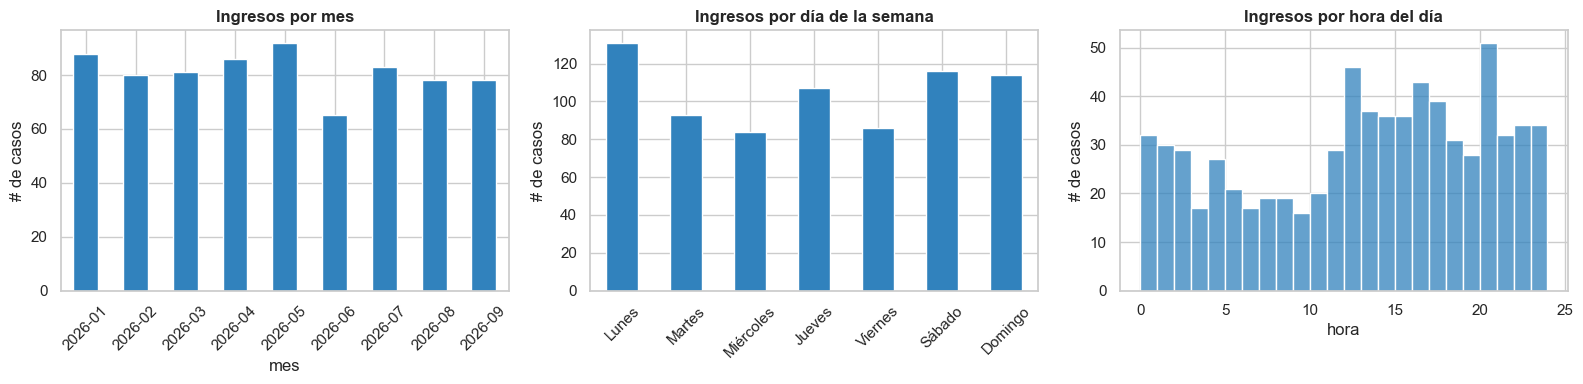

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["mes_recepcion"] = df["FECHA RECEPCIÓN"].dt.to_period("M").astype(str)
df["mes_recepcion"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#3182bd")
axes[0].set(title="Ingresos por mes", xlabel="mes", ylabel="# de casos")
axes[0].tick_params(axis="x", rotation=45)

dias_semana_es = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
conteo_dia = df["FECHA RECEPCIÓN"].dt.dayofweek.value_counts().reindex(range(7)).fillna(0)
conteo_dia.index = dias_semana_es
conteo_dia.plot(kind="bar", ax=axes[1], color="#3182bd")
axes[1].set(title="Ingresos por día de la semana", xlabel="", ylabel="# de casos")
axes[1].tick_params(axis="x", rotation=45)

sns.histplot(df["hora_recepcion_num"].dropna(), bins=24, ax=axes[2], color="#3182bd")
axes[2].set(title="Ingresos por hora del día", xlabel="hora", ylabel="# de casos")

plt.tight_layout()
plt.show()


**Resultado.** El volumen mensual es estable: entre 65 y 92 ingresos, con una media de 81.2 al mes y sin
tendencia creciente ni decreciente a lo largo de los nueve meses registrados. Mayo (92) y enero (88) son
los meses más altos; junio (65), el más bajo.

Por día de la semana aparece un patrón consistente con la actividad de un servicio forense urbano: el
lunes concentra el mayor número de ingresos (131), seguido de sábado (116) y domingo (114), mientras que
el miércoles registra el mínimo (84). La razón entre el máximo y el mínimo es de 1.56. El exceso de fin
de semana y lunes es característico de muertes violentas y accidentales.

La cobertura llega hasta el 27 de septiembre de 2026; faltan los últimos tres meses del año, lo que debe
tenerse en cuenta al extrapolar cualquier volumen anual.

## 6. Distribución de la variable de estatus

La variable `INGRESA COMO IDENTIFICADO / NO IDENTIFICADO` está desbalanceada, pero conviene precisar su
papel: **no es la variable objetivo de un clasificador**. El proyecto es de recuperación por similitud
entre fichas de búsqueda y registros de necropsia, y no existen pares etiquetados match/no-match que
permitan entrenar un modelo supervisado.

Se emplea como **estratificador analítico**, es decir, como variable que separa subpoblaciones relevantes
para el diseño del índice de recuperación. Por eso no se aplican técnicas de rebalanceo.

INGRESA COMO IDENTIFICADO / NO IDENTIFICADO
IDENTIFICADO       568
NO IDENTIFICADO    163

Razón de desbalance identificado:no-identificado = 3.48:1


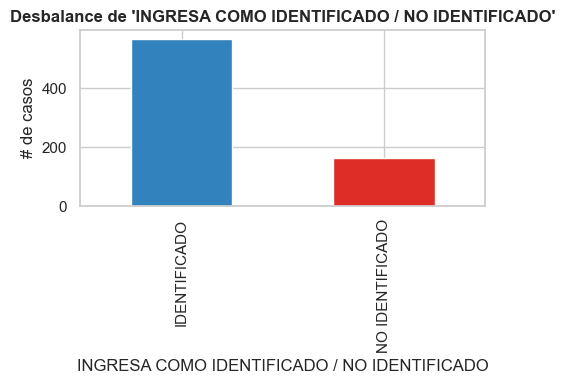


De los 163 casos NO IDENTIFICADOS, la sección 5.4 ya mostró que se dividen en n=83 (universo objetivo del cotejo) y n=80 (gold standard, se reconocieron después).


In [53]:
conteo_identificacion = df["INGRESA COMO IDENTIFICADO / NO IDENTIFICADO"].value_counts()
print(conteo_identificacion.to_string())
razon = conteo_identificacion.max() / conteo_identificacion.min()
print(f"\nRazón de desbalance identificado:no-identificado = {razon:.2f}:1")

fig, ax = plt.subplots(figsize=(5, 4))
conteo_identificacion.plot(kind="bar", ax=ax, color=["#3182bd", "#de2d26"])
ax.set(title="Desbalance de 'INGRESA COMO IDENTIFICADO / NO IDENTIFICADO'", ylabel="# de casos")
plt.tight_layout()
plt.show()

print(f"\nDe los {conteo_identificacion.get('NO IDENTIFICADO', 0)} casos NO IDENTIFICADOS, "
      f"la sección 5.4 ya mostró que se dividen en n=83 (universo objetivo del cotejo) "
      f"y n=80 (gold standard, se reconocieron después).")


**Resultado.** La razón de desbalance es de 3.48:1 (568 identificados frente a 163 no identificados).
Como se indicó, no se aplica sobremuestreo ni submuestreo: el valor de esta variable para el proyecto no
está en predecirla, sino en que delimita la población de trabajo. Los 163 casos no identificados se
dividen, según la sección 5.4, en los 83 que siguen pendientes y los 80 que sirven de referencia para
evaluar el sistema.

## 7. Preprocesamiento

Esta sección aplica las correcciones y transformaciones que requieren criterio, apoyándose en la
evidencia recogida en las secciones 2 a 6: tratamiento de faltantes, de atípicos, de inconsistencias
lógicas y de alta cardinalidad.

### 7.1 Faltantes

**Por qué no se imputa por moda.** Un faltante en `DESCRIPCIÓN TATUAJES` puede significar tres cosas
distintas: que la persona no tiene tatuajes, que los tiene pero no se describieron, o que se ignora.
Sustituir por la moda eliminaría precisamente la distinción que el proyecto necesita para evaluar si el
campo sirve para el cotejo. En `OCUPACIÓN` y `ESTADO CIVIL`, el valor `SE IGNORA` ya es la categoría que
el propio SEMEFO asignó al capturar; reemplazarla introduciría información inexistente.

**Verificación del mecanismo de faltante.** Si el mecanismo fuera completamente aleatorio (MCAR), la tasa
de "no se sabe" debería ser similar entre cuerpos identificados y no identificados. Se contrasta esa
hipótesis con los datos:

In [54]:
def tasa_faltante_por_grupo(columna, literales_faltante, grupo_col="INGRESA COMO IDENTIFICADO / NO IDENTIFICADO"):
    valores = df[columna].astype(str).str.strip().str.upper()
    es_faltante = df[columna].isna() | valores.isin(literales_faltante)
    tabla = pd.crosstab(df[grupo_col], es_faltante, normalize="index") * 100
    tabla.columns = ["con_dato", "faltante_o_se_ignora"] if False else tabla.columns
    chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(df[grupo_col], es_faltante))
    return tabla, p

print("Tasa de '% sin dato / SE IGNORA' por estatus de identificación (evidencia de faltante informativo):\n")
for columna, literales in [
    ("OCUPACIÓN", {"SE IGNORA"}),
    ("ESTADO CIVIL", {"SE IGNORA"}),
]:
    tabla, p = tasa_faltante_por_grupo(columna, literales)
    print(f"--- {columna} ---")
    print(tabla.round(1))
    print(f"chi2 test de independencia vs. estatus de identificación: p = {'<0.001' if p < 0.001 else round(p,4)}")
    print()

# Edad indeterminada (no se pudo parsear/pericialmente indeterminada) por estatus de identificación
edad_indeterminada = df["edad_unidad_original"].isin(["INDETERMINADO_SE_IGNORA", "SIN_PARSEAR"])
tabla_edad = pd.crosstab(df["INGRESA COMO IDENTIFICADO / NO IDENTIFICADO"], edad_indeterminada, normalize="index") * 100
chi2_e, p_e, _, _ = stats.chi2_contingency(pd.crosstab(df["INGRESA COMO IDENTIFICADO / NO IDENTIFICADO"], edad_indeterminada))
print("--- edad_anios no determinada ---")
print(tabla_edad.round(1))
print(f"chi2 test: p = {'<0.001' if p_e < 0.001 else round(p_e,4)}")


Tasa de '% sin dato / SE IGNORA' por estatus de identificación (evidencia de faltante informativo):



--- OCUPACIÓN ---
OCUPACIÓN                                    False  True 
INGRESA COMO IDENTIFICADO / NO IDENTIFICADO              
IDENTIFICADO                                  84.2   15.8
NO IDENTIFICADO                               54.0   46.0
chi2 test de independencia vs. estatus de identificación: p = <0.001

--- ESTADO CIVIL ---
ESTADO CIVIL                                 False  True 
INGRESA COMO IDENTIFICADO / NO IDENTIFICADO              
IDENTIFICADO                                  83.8   16.2
NO IDENTIFICADO                               54.0   46.0
chi2 test de independencia vs. estatus de identificación: p = <0.001

--- edad_anios no determinada ---
edad_unidad_original                         False  True 
INGRESA COMO IDENTIFICADO / NO IDENTIFICADO              
IDENTIFICADO                                  99.5    0.5
NO IDENTIFICADO                               88.3   11.7
chi2 test: p = <0.001


**Resultado.** La tasa de dato ausente es sistemáticamente mayor entre los cuerpos no identificados:
46.0% frente a 15.8% en ocupación, 46.0% frente a 16.2% en estado civil, y 11.7% frente a 0.5% en edad.
Las tres asociaciones son significativas (χ², p < 0.001).

La interpretación sustantiva es directa: no hay ocupación, estado civil ni edad exacta porque no hay
nadie que haya identificado a la persona y aportado esos datos. La misma condición que define a la
población objetivo del proyecto es la causa del faltante. En términos formales se trata de un **faltante
informativo**, y su patrón constituye en sí mismo una señal útil: un registro con muchos campos
`SE IGNORA` pertenece con alta probabilidad al universo de casos difíciles de identificar.

**Decisión por columna:**

In [55]:
tabla_decision_faltantes = pd.DataFrame([
    {"columna": "INHUMADO", "pct_problema": 100.0, "decision": "ELIMINAR", "razon": "100% vacía, cero información."},
    {"columna": "MÉDICO COLEGIADO", "pct_problema": round(df['MÉDICO COLEGIADO'].isna().mean()*100,1),
     "decision": "ELIMINAR", "razon": "Nula en la enorme mayoría de los casos."},
    {"columna": "FOTOGRAFA", "pct_problema": round(df['FOTOGRAFA'].isna().mean()*100,1),
     "decision": "ELIMINAR del análisis cuantitativo", "razon": "Nula en >2/3 de los casos; se conserva solo si se necesita para auditoría de carga de trabajo."},
    {"columna": "DÍAS HASTA LA ENTREGA O INHUMACIÓN (original)", "pct_problema": 100.0,
     "decision": "ELIMINAR Y RECALCULAR", "razon": "Corrupta (fórmula a texto); se usa dias_entrega recalculada desde fechas reales."},
    {"columna": "OCUPACIÓN", "pct_problema": round((df['OCUPACIÓN'].astype(str).str.upper().str.strip()=='SE IGNORA').mean()*100,1),
     "decision": "CONSERVAR 'SE IGNORA' como categoría explícita", "razon": "Faltante informativo (MNAR); no imputar por moda."},
    {"columna": "ESTADO CIVIL", "pct_problema": round((df['ESTADO CIVIL'].astype(str).str.upper().str.strip()=='SE IGNORA').mean()*100,1),
     "decision": "CONSERVAR 'SE IGNORA' como categoría explícita", "razon": "Mismo argumento MNAR."},
    {"columna": "DESCRIPCIÓN TATUAJES", "pct_problema": round(100*es_relleno.mean(),1),
     "decision": "CONSERVAR, distinguir 'no tiene' de 'no se consignó'", "razon": "Único texto individualizante; imputar borraría la distinción sustantiva."},
    {"columna": "edad_anios / horas_crono", "pct_problema": round(100*df['edad_anios'].isna().mean(),1),
     "decision": "CONSERVAR NaN + categoría 'edad_unidad_original'", "razon": "Indeterminación pericial real, no error de captura."},
])
tabla_decision_faltantes


,columna,pct_problema,decision,razon
0,INHUMADO,100.0,ELIMINAR,"100% vacía, cero información."
1,MÉDICO COLEGIADO,98.1,ELIMINAR,Nula en la enorme mayoría de los casos.
2,FOTOGRAFA,67.4,ELIMINAR del análisis cuantitativo,Nula en >2/3 de los casos; se conserva solo si se necesita para auditoría de...
3,DÍAS HASTA LA ENTREGA O INHUMACIÓN (original),100.0,ELIMINAR Y RECALCULAR,Corrupta (fórmula a texto); se usa dias_entrega recalculada desde fechas rea...
4,OCUPACIÓN,22.3,CONSERVAR 'SE IGNORA' como categoría explícita,Faltante informativo (MNAR); no imputar por moda.
5,ESTADO CIVIL,22.8,CONSERVAR 'SE IGNORA' como categoría explícita,Mismo argumento MNAR.
6,DESCRIPCIÓN TATUAJES,72.5,"CONSERVAR, distinguir 'no tiene' de 'no se consignó'",Único texto individualizante; imputar borraría la distinción sustantiva.
7,edad_anios / horas_crono,3.1,CONSERVAR NaN + categoría 'edad_unidad_original',"Indeterminación pericial real, no error de captura."


### 7.2 Atípicos

En datos forenses el valor atípico suele ser el caso de mayor interés. Un feto o un neonato no es un
error de captura en la columna de edad, sino una categoría de caso real; un cuerpo que tarda 215 días en
ser entregado indica complicaciones legales o de identificación, que es exactamente el tipo de caso que
el proyecto busca atender.

Por ello se combinan límites por rango intercuartílico con reglas de dominio, y los atípicos se **marcan
con bandera** en lugar de eliminarse.

In [56]:
def detectar_atipicos_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (serie < lo) | (serie > hi), lo, hi

df["edad_atipica_iqr"], lo_edad, hi_edad = detectar_atipicos_iqr(df["edad_anios"])
df["dias_entrega_atipico_iqr"], lo_dias, hi_dias = detectar_atipicos_iqr(df["dias_entrega"])

print(f"Edad: límites IQR [{lo_edad:.1f}, {hi_edad:.1f}] años -> {df['edad_atipica_iqr'].sum()} casos marcados")
print(f"Días de entrega: límites IQR [{lo_dias:.1f}, {hi_dias:.1f}] días -> {df['dias_entrega_atipico_iqr'].sum()} casos marcados")

# Regla de dominio adicional: casos perinatales (edad < 1 año o en semanas de gestación) son de interés,
# no error de captura.
df["caso_perinatal"] = (df["edad_unidad_original"] == "SEMANAS_GESTACION_FETO") | (df["edad_anios"].fillna(99) < 1)
print(f"\nCasos perinatales (feto/neonato, edad < 1 año): {df['caso_perinatal'].sum()}")

def mostrar_atipicos(mascara, columnas, orden, titulo, ascendente=True):
    """Muestra ejemplos de atípicos; si el criterio no marca ninguno, lo reporta en texto
    en lugar de imprimir una tabla vacía."""
    subconjunto = df.loc[mascara, columnas]
    print(f"\n{titulo}")
    if subconjunto.empty:
        print("  -> El criterio IQR no marca ningún caso en esta variable (distribución sin cola extrema).")
    else:
        display(subconjunto.sort_values(orden, ascending=ascendente).head(8))

mostrar_atipicos(
    df["edad_atipica_iqr"],
    ["id_registro", "edad_anios", "edad_unidad_original", "TIPO DE INDICIO", "TIPO DE MUERTE"],
    "edad_anios",
    "Ejemplos de atípicos de edad (id_registro seudonimizado + edad + contexto, SIN texto libre):",
)

mostrar_atipicos(
    df["dias_entrega_atipico_iqr"],
    ["id_registro", "dias_entrega", "ESTADO ACTUAL DEL INDICIO", "TIPO DE INDICIO"],
    "dias_entrega",
    "Ejemplos de atípicos de días hasta la entrega (el máximo real, caso de alto interés para seguimiento):",
    ascendente=False,
)


Edad: límites IQR [-16.8, 101.2] años -> 0 casos marcados
Días de entrega: límites IQR [-1.5, 2.5] días -> 82 casos marcados

Casos perinatales (feto/neonato, edad < 1 año): 43

Ejemplos de atípicos de edad (id_registro seudonimizado + edad + contexto, SIN texto libre):
  -> El criterio IQR no marca ningún caso en esta variable (distribución sin cola extrema).

Ejemplos de atípicos de días hasta la entrega (el máximo real, caso de alto interés para seguimiento):


,id_registro,dias_entrega,ESTADO ACTUAL DEL INDICIO,TIPO DE INDICIO
57,6208ef0f7750,215.0,ENTREGADO,CADÁVER
132,d2f483672c02,214.0,ENTREGADO,RESTO ÓSEO
89,69f59c273b6e,165.0,ENTREGADO,CADÁVER
315,7a20311cf7a4,142.0,ENTREGADO,CADÁVER
187,d6061bbee6cf,126.0,ENTREGADO,CADÁVER
177,01d54579da44,126.0,ENTREGADO,CADÁVER
221,9b871512327c,123.0,ENTREGADO,CADÁVER
158,ff2ccb6ba423,107.0,ENTREGADO,FETO


**Resultado.** Los dos criterios se comportan de forma muy distinta:

- **Edad**: el rango intercuartílico produce límites de [−16.8, 101.2] años, que no excluyen ningún caso.
  El criterio estadístico resulta inoperante aquí porque la distribución es amplia y casi simétrica. Los
  43 casos perinatales se identifican mediante regla de dominio, no por IQR.
- **Días hasta la entrega**: límites de [−1.5, 2.5] días y 82 casos marcados. Dado que el 83.3% de las
  entregas ocurre en un día o menos, el IQR es muy estrecho y clasifica como atípico cualquier caso que
  tarde tres días o más.

Los casos extremos (215, 214, 165 días) corresponden a cuerpos que permanecieron en cámara de
conservación o en antropología. No son errores: son los casos que más tiempo tardaron en resolverse, y
por tanto los de mayor interés para el proyecto. Los 85 registros sin fecha de entrega corresponden a los
70 cuerpos en cámara de conservación y 12 en antropología que seguían sin entregarse al corte.

### 7.3 Inconsistencias lógicas

Se revisan las relaciones cronológicas que deben cumplirse entre las tres fechas del registro
(recepción ≤ necropsia ≤ entrega) y la coherencia entre la bandera de tatuajes y su descripción.

In [57]:
df["fecha_necropsia_antes_de_recepcion"] = df["FECHA NECROPSIA"] < df["FECHA RECEPCIÓN"]
casos_fecha_inconsistente = df.loc[
    df["fecha_necropsia_antes_de_recepcion"],
    ["id_registro", "FECHA RECEPCIÓN", "FECHA NECROPSIA"],
].copy()
casos_fecha_inconsistente["diferencia_dias"] = (
    casos_fecha_inconsistente["FECHA RECEPCIÓN"] - casos_fecha_inconsistente["FECHA NECROPSIA"]
).dt.days
print(f"{len(casos_fecha_inconsistente)} casos con FECHA NECROPSIA anterior a FECHA RECEPCIÓN "
      f"(distintos del typo de año ya corregido en la sección 3.4):")
display(casos_fecha_inconsistente)
print("\nLos 3 casos son desfases de 1 día dentro del mismo mes, sin ningún otro campo que indique cuál")
print("fecha es la correcta. Se marcan con bandera ('fecha_necropsia_antes_de_recepcion') para seguimiento")
print("manual con el SEMEFO, sin corregir a ciegas.")
print(f"\nTotal de inconsistencias de fecha encontradas en el libro: "
      f"{int(df['fecha_recepcion_corregida_anio'].sum())} corregida(s) + {len(casos_fecha_inconsistente)} "
      f"pendiente(s) de seguimiento manual.")


3 casos con FECHA NECROPSIA anterior a FECHA RECEPCIÓN (distintos del typo de año ya corregido en la sección 3.4):


,id_registro,FECHA RECEPCIÓN,FECHA NECROPSIA,diferencia_dias
453,48f89b630677,2026-06-13,2026-06-12,1
536,da6813d10025,2026-07-16,2026-07-15,1
541,2d86377d4cc3,2026-07-18,2026-07-17,1



Los 3 casos son desfases de 1 día dentro del mismo mes, sin ningún otro campo que indique cuál
fecha es la correcta. Se marcan con bandera ('fecha_necropsia_antes_de_recepcion') para seguimiento
manual con el SEMEFO, sin corregir a ciegas.

Total de inconsistencias de fecha encontradas en el libro: 1 corregida(s) + 3 pendiente(s) de seguimiento manual.


**Días de entrega negativos.** Por regla de dominio, `dias_entrega` no puede ser negativo: un cuerpo no
puede entregarse antes de concluir la necropsia. Este caso no fue detectado por el criterio de rango
intercuartílico, ya que −1 día cae dentro de sus límites: es un ejemplo de por qué las reglas de dominio
complementan a los criterios estadísticos.

In [58]:
df["dias_entrega_negativo"] = df["dias_entrega"] < 0
n_dias_negativos = int(df["dias_entrega_negativo"].sum())
print(f"Casos con días de entrega negativos (imposible por regla de dominio): {n_dias_negativos}")
if n_dias_negativos:
    display(df.loc[df["dias_entrega_negativo"], ["id_registro", "FECHA NECROPSIA", "FECHA DE ENTREGA", "dias_entrega"]])
print("Se marca con bandera ('dias_entrega_negativo') para seguimiento manual, sin corregir a ciegas:")
print("con solo la fecha (sin hora) no se puede saber si el problema está en la fecha de necropsia o en")
print("la de entrega.")


Casos con días de entrega negativos (imposible por regla de dominio): 1


,id_registro,FECHA NECROPSIA,FECHA DE ENTREGA,dias_entrega
633,709df012e236,2026-08-23,2026-08-22,-1.0


Se marca con bandera ('dias_entrega_negativo') para seguimiento manual, sin corregir a ciegas:
con solo la fecha (sin hora) no se puede saber si el problema está en la fecha de necropsia o en
la de entrega.


**Coherencia entre la bandera `TATUAJES` y su descripción.** Se contrastan ambos campos para detectar
registros donde uno contradice al otro.

In [59]:
tat_norm = df["TATUAJES"].astype(str).str.strip().str.upper()
desc_tat_norm = df["DESCRIPCIÓN TATUAJES"].astype(str).str.strip().str.upper()
tiene_desc_sustantiva = ~(df["DESCRIPCIÓN TATUAJES"].isna() | desc_tat_norm.isin(LITERALES_NO_APLICA_TATUAJES))

# Caso A: TATUAJES=SI pero sin descripción sustantiva -> pérdida de información individualizante.
mask_si_sin_desc = (tat_norm == "SI") & ~tiene_desc_sustantiva
n_si_sin_desc = int(mask_si_sin_desc.sum())
n_si_total = int((tat_norm == "SI").sum())
print(f"TATUAJES=SI: {n_si_total} casos. De esos, SIN descripción sustantiva: {n_si_sin_desc} "
      f"({100*n_si_sin_desc/n_si_total:.1f}%). Esta cifra se recalcula en vivo y puede diferir en ±1-2 "
      f"de cifras citadas en planes previos, según exactamente qué literales se tratan como relleno.")
df["tatuajes_si_sin_descripcion"] = mask_si_sin_desc

# Caso B: TATUAJES=NO pero con descripción sustantiva -> contradicción de captura, se corrige la bandera.
mask_no_con_desc = (tat_norm == "NO") & tiene_desc_sustantiva
n_no_con_desc = int(mask_no_con_desc.sum())
print(f"\nTATUAJES=NO con descripción sustantiva (contradicción de captura): {n_no_con_desc} casos.")
print("Se corrige la bandera TATUAJES a 'SI' en estos casos (la descripción prueba que sí se documentó")
print("una marca individualizante), dejando evidencia en 'tatuajes_corregido_por_descripcion'.")
df["tatuajes_corregido_por_descripcion"] = mask_no_con_desc
df.loc[mask_no_con_desc, "TATUAJES"] = "SI"


TATUAJES=SI: 251 casos. De esos, SIN descripción sustantiva: 57 (22.7%). Esta cifra se recalcula en vivo y puede diferir en ±1-2 de cifras citadas en planes previos, según exactamente qué literales se tratan como relleno.

TATUAJES=NO con descripción sustantiva (contradicción de captura): 6 casos.
Se corrige la bandera TATUAJES a 'SI' en estos casos (la descripción prueba que sí se documentó
una marca individualizante), dejando evidencia en 'tatuajes_corregido_por_descripcion'.


### 7.4 Alta cardinalidad

Se reduce la cardinalidad de las variables con cientos de categorías mediante agrupación semántica
(causa de muerte a familias, ocupaciones raras a una categoría común), tokenización de la columna
multi-etiqueta de muestras, y separación de la columna de frigoríficos, que hoy mezcla el estatus del
cuerpo con su ubicación física.

**Por qué no se aplica one-hot ni binary encoding.** El destino de estas variables es un índice de
búsqueda por similitud (*embeddings* + Databricks Vector Search), no una matriz de diseño para un modelo
supervisado. Siguiendo el mismo criterio que `01_extraccion_fichas_llm.py` aplica del lado ante-mortem
—construir texto canónico a partir de campos estructurados—, conviene reducir la cardinalidad a un
vocabulario controlado y conservar el valor como texto normalizado. Un one-hot de 328 causas de muerte
generaría una matriz dispersa de gran tamaño y perdería la información semántica que un *embedding*
aprovecha mejor como cadena corta.

CAUSA DE MUERTE: 328 categorías originales -> 7 familias.
causa_muerte_familia
TRAUMATISMO                              270
CARDIOVASCULAR_RESPIRATORIO_DIGESTIVO    230
ASFIXIA                                  124
OTRA                                      45
PERINATAL                                 39
INDETERMINADA                             21
SIN_DATO                                   2


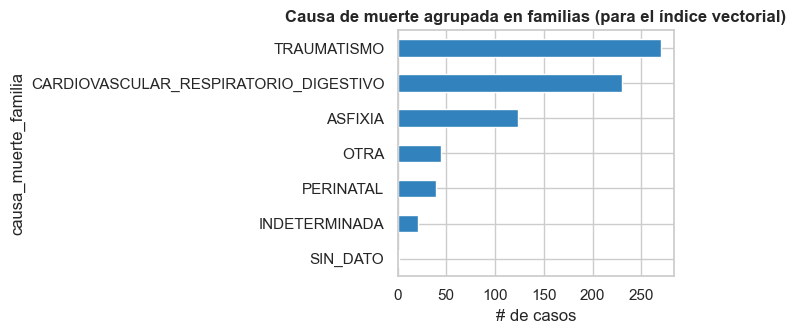

In [60]:
# --- CAUSA DE MUERTE -> familias por palabra clave (reduce cardinalidad para el índice, no reemplaza
#     el valor original, que se conserva intacto para trazabilidad). ---
def familia_causa_muerte(texto):
    if pd.isna(texto):
        return "SIN_DATO"
    t = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode().upper()
    if any(k in t for k in ["INDETERMINAD"]):
        return "INDETERMINADA"
    if any(k in t for k in ["TRAUMA", "MACHACAMIENTO", "LACERACION", "HERIDA", "PROYECTIL", "ARMA DE FUEGO",
                             "CRANEOENCEFALIC", "RAQUIMEDULAR", "POLICONTUNDIDO"]):
        return "TRAUMATISMO"
    if any(k in t for k in ["ASFIXIA", "ANOXIA", "AHORCA", "SUMERSION", "ESTRANGULA", "SOFOCACION"]):
        return "ASFIXIA"
    if any(k in t for k in ["MATERNO FETAL", "MATERNO-FETAL", "PERINATAL", "PREMATUR", "RECONOCIMIENTO) FETO"]):
        return "PERINATAL"
    if any(k in t for k in ["INFARTO", "CARDIO", "CIRROSIS", "TROMBOEMBOLIA", "EDEMA PULMONAR",
                             "SEPSIS", "NEUMONIA", "SANGRADO DE TUBO DIGESTIVO", "HEMORRAGIA"]):
        return "CARDIOVASCULAR_RESPIRATORIO_DIGESTIVO"
    return "OTRA"

df["causa_muerte_familia"] = df["CAUSA DE MUERTE"].map(familia_causa_muerte)
tabla_familias = df["causa_muerte_familia"].value_counts()
print(f"CAUSA DE MUERTE: {df['CAUSA DE MUERTE'].nunique()} categorías originales -> "
      f"{df['causa_muerte_familia'].nunique()} familias.")
print(tabla_familias.to_string())

fig, ax = plt.subplots(figsize=(7, 3.5))
tabla_familias.sort_values().plot.barh(ax=ax, color="#3182bd")
ax.set(title="Causa de muerte agrupada en familias (para el índice vectorial)", xlabel="# de casos")
plt.tight_layout()
plt.show()


In [61]:
# --- OCUPACIÓN -> categorías raras (debajo de un umbral) a 'OTRA_OCUPACION'; SE IGNORA se conserva. ---
UMBRAL_RARA = max(5, round(0.01 * len(df)))  # categorías con menos del 1% de los casos (mínimo 5)
frecuencia_ocupacion = df["OCUPACIÓN"].value_counts()
categorias_frecuentes = set(frecuencia_ocupacion[frecuencia_ocupacion >= UMBRAL_RARA].index) | {"SE IGNORA", "NINGUNA"}

def agrupar_rara(valor):
    if pd.isna(valor):
        return valor
    return valor if valor in categorias_frecuentes else "OTRA_OCUPACION"

df["ocupacion_agrupada"] = df["OCUPACIÓN"].map(agrupar_rara)
print(f"Umbral de categoría rara: < {UMBRAL_RARA} casos ({100*UMBRAL_RARA/len(df):.1f}%)")
print(f"OCUPACIÓN: {df['OCUPACIÓN'].nunique()} categorías originales -> {df['ocupacion_agrupada'].nunique()} tras agrupar.")
print(df["ocupacion_agrupada"].value_counts().head(15).to_string())


Umbral de categoría rara: < 7 casos (1.0%)
OCUPACIÓN: 161 categorías originales -> 15 tras agrupar.
ocupacion_agrupada
OTRA_OCUPACION    214
SE IGNORA         163
NINGUNA           113
ESTUDIANTE         30
COMERCIANTE        29
EMPLEADO           28
JUBILADO           26
CHOFER             25
ALBAÑIL            25
AMA DE CASA        19
VIGILANTE          18
DESEMPLEADO        16
MECANICO            8
OBRERO              8
JARDINERO           7


In [62]:
# --- MUESTRAS -> tokenizar el separador '+'/'Y' a multi-hot (es una columna multi-etiqueta, no nominal). ---
SINONIMOS_MUESTRA = {
    "TOXI": "TOXICOLOGIA", "TOXICO": "TOXICOLOGIA", "TOXICOLOGICO": "TOXICOLOGIA", "TXOI": "TOXICOLOGIA",
    "FTA": "FTA", "GENETICA": "GENETICA", "GENÉTICA": "GENETICA", "PERFIL": "GENETICA",
    "BALISTICA": "BALISTICA", "ELEMENTO BALISTICO": "BALISTICA", "ELMENTO BALISTICO": "BALISTICA",
    "ENTOMOLOGIA": "ENTOMOLOGIA", "ENTOMOFAUNA": "ENTOMOLOGIA", "ENTOMO": "ENTOMOLOGIA",
    "PATOLOGIA": "PATOLOGIA", "PATOLOGÍA": "PATOLOGIA", "PATO": "PATOLOGIA",
    "NINGUNA": "NINGUNA", "NINGUNO": "NINGUNA", "NIGUNA": "NINGUNA", "NNINGUNO": "NINGUNA",
    "N/A": "SIN_DATO", "NA": "SIN_DATO",
}

def tokenizar_muestras(texto):
    if pd.isna(texto):
        return []
    t = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode().upper()
    piezas = re.split(r"[+,]|(?<!TORAX)\bY\b", t)
    etiquetas = set()
    for pieza in piezas:
        pieza = pieza.strip(" .'´")
        if not pieza:
            continue
        etiquetas.add(SINONIMOS_MUESTRA.get(pieza, "OTRA_MUESTRA"))
    return sorted(etiquetas) if etiquetas else ["SIN_DATO"]

df["muestras_tokens"] = df["MUESTRAS"].map(tokenizar_muestras)
categorias_muestra = ["TOXICOLOGIA", "FTA", "GENETICA", "BALISTICA", "ENTOMOLOGIA", "PATOLOGIA",
                      "NINGUNA", "OTRA_MUESTRA", "SIN_DATO"]
for cat in categorias_muestra:
    df[f"muestra_{cat.lower()}"] = df["muestras_tokens"].map(lambda ts, c=cat: c in ts)

conteo_multihot = df[[f"muestra_{c.lower()}" for c in categorias_muestra]].sum().sort_values(ascending=False)
print("Multi-hot de MUESTRAS (un caso puede tener varias etiquetas a la vez):")
print(conteo_multihot.to_string())


Multi-hot de MUESTRAS (un caso puede tener varias etiquetas a la vez):
muestra_toxicologia     452
muestra_fta             387
muestra_otra_muestra    164
muestra_ninguna          88
muestra_balistica        20
muestra_patologia        14
muestra_entomologia      12
muestra_genetica          6
muestra_sin_dato          0


In [63]:
# --- Columna de frigoríficos -> separar estatus de ubicación física (hoy mezcla ambos). ---
PATRON_GAVETA = re.compile(r"^[A-Za-z]\s?\d\s?N\s?\d$")
ESTATUS_ENTREGADO = {"ENTREGADO", "ENTREGADA"}  # ya colapsado por TYPOS_GLOBALES en la sección 3
UBICACION_ALTERNA_CONOCIDA = {"ANTROPOLOGÍA", "GENETICA", "PATOLOGÍA", "RESGUARDO EN HOSPITAL",
                               "GUARDADO EN HOSPITAL", "LABORATORIO DE ANTROPOLOGÍA",
                               "RESGUARDO EN HOSPITAL DEL NIÑO Y LA MUJER", "RESGUARDO EN HOSPITAL GENERAL"}

def descomponer_frigorifico(valor):
    if pd.isna(valor):
        return pd.Series({"ingresa_frigorifico": np.nan, "gaveta": np.nan, "ubicacion_alterna": np.nan})
    v = str(valor).strip().upper()
    if PATRON_GAVETA.match(v):
        return pd.Series({"ingresa_frigorifico": "SI", "gaveta": v.replace(" ", ""), "ubicacion_alterna": np.nan})
    if v in ESTATUS_ENTREGADO:
        return pd.Series({"ingresa_frigorifico": "NO", "gaveta": np.nan, "ubicacion_alterna": np.nan})
    if v in UBICACION_ALTERNA_CONOCIDA:
        return pd.Series({"ingresa_frigorifico": "NO", "gaveta": np.nan, "ubicacion_alterna": v})
    return pd.Series({"ingresa_frigorifico": "SIN_DATO", "gaveta": np.nan, "ubicacion_alterna": v})

col_frigo = "¿EL CUERPO INGRESA A FRIGORIFICOS? INDIQUE EN QUE GAVETA"
descompuesta = df[col_frigo].map(descomponer_frigorifico).apply(pd.Series)
df[["ingresa_frigorifico", "gaveta", "ubicacion_alterna"]] = descompuesta

print("ingresa_frigorifico:")
print(df["ingresa_frigorifico"].value_counts(dropna=False).to_string())
print(f"\ngaveta: {df['gaveta'].notna().sum()} casos con código de gaveta identificado")
print("\nubicacion_alterna:")
print(df["ubicacion_alterna"].value_counts(dropna=False).to_string())


ingresa_frigorifico:
ingresa_frigorifico
NO     660
SI      69
NaN      2

gaveta: 69 casos con código de gaveta identificado

ubicacion_alterna:
ubicacion_alterna
NaN                                          709
ANTROPOLOGÍA                                  11
RESGUARDO EN HOSPITAL                          5
PATOLOGÍA                                      1
LABORATORIO DE ANTROPOLOGÍA                    1
GENETICA                                       1
GUARDADO EN HOSPITAL                           1
RESGUARDO EN HOSPITAL GENERAL                  1
RESGUARDO EN HOSPITAL DEL NIÑO Y LA MUJER      1


**Resultado.** Las cuatro transformaciones reducen la cardinalidad de forma sustancial:

| Variable | Antes | Después |
|---|---|---|
| Causa de muerte | 328 categorías | 7 familias |
| Ocupación | 161 categorías | 15 grupos |
| Muestras | 172 cadenas | 9 indicadores multi-etiqueta |
| Frigoríficos | 65 valores mezclados | 3 columnas separadas |

Las familias de causa de muerte quedan encabezadas por traumatismo (270), cardiovascular/respiratorio/
digestivo (230) y asfixia (124). En ocupación, las categorías agrupadas bajo `OTRA_OCUPACION` (214) más
`SE IGNORA` (163) y `NINGUNA` (113) suman 490 de 731 casos: **la ocupación aporta poca información
utilizable para el cotejo**, tanto por su dispersión como por su alta tasa de no captura.

La tokenización de muestras revela que toxicología (452) y FTA (387) son rutinarias, mientras que
genética solo aparece en 6 casos. Esto último es relevante: siendo la genética un identificador primario,
su registro en este libro es demasiado escaso para apoyarse en él, y habría que recurrir a los registros
del laboratorio.

La separación de la columna de frigoríficos muestra que solo 69 cuerpos ingresaron a gaveta, mientras que
la mayoría de los valores de esa columna describían en realidad el estatus de entrega.

### 7.5 Exportación del conjunto depurado

Antes de escribir el archivo se verifica que ninguna columna de datos personales haya sobrevivido al
procesamiento, y se deja constancia de qué columnas de texto libre se conservan y por qué.

In [64]:
assert not any(c in df.columns for c in COLS_PII), "¡Hay columnas PII en el dataframe final!"

columnas_descartadas_definitivamente = ["INHUMADO", "DÍAS HASTA LA ENTREGA O INHUMACIÓN"]

# 'LUGAR DONDE OCURRIÓ EL HECHO' se excluye del CSV: son direcciones de calle y en 53 casos coinciden
# literalmente con el domicilio del fallecido, que sí se eliminó como PII. Se reintroduciría por la
# puerta de atrás. 'MUNICIPIO DONDE OCURRIÓ EL HECHO' conserva el nivel geográfico que sirve de
# variable de bloqueo en el cotejo; la dirección exacta no aporta poder discriminante adicional.
COLS_PII_INDIRECTA = ["LUGAR DONDE OCURRIÓ EL HECHO"]
df_final = df.drop(columns=[c for c in columnas_descartadas_definitivamente + COLS_PII_INDIRECTA
                            if c in df.columns])

_dom = df_crudo.loc[df.index, "DOMICILIO DE RESIDENCIA"].astype(str).str.strip().str.upper()
_lug = df["LUGAR DONDE OCURRIÓ EL HECHO"].astype(str).str.strip().str.upper()
_coincidencias = ((_dom == _lug) & (_dom.str.len() >= 10)).sum()
print(f"Direcciones del hecho idénticas al domicilio del fallecido: {_coincidencias} "
      f"-> columna excluida del CSV por PII indirecta\n")

RUTA_SALIDA = Path("..") / "Datos" / "necropsias_limpio.csv"
df_final.to_csv(RUTA_SALIDA, index=False, encoding="utf-8-sig")

print(f"Escrito: {RUTA_SALIDA.resolve()}")
print(f"Shape final: {df_final.shape}")
_texto_en_csv = [c for c in COLS_TEXTO_LIBRE if c in df_final.columns]
print(f"\nColumnas de texto libre conservadas en el CSV (ver advertencia en Conclusiones): {_texto_en_csv}")
print(f"Columnas de texto libre excluidas del CSV por PII indirecta: {COLS_PII_INDIRECTA}")
print(f"Columnas de personal (ya anonimizadas a códigos): {COLS_PERSONAL}")
verificacion_pii = [c for c in df_final.columns if c in COLS_PII + COLS_PII_INDIRECTA]
print(f"\nVerificación final — columnas PII presentes en el CSV: {verificacion_pii} (debe ser lista vacía)")


Direcciones del hecho idénticas al domicilio del fallecido: 50 -> columna excluida del CSV por PII indirecta

Escrito: /Users/jaquelinevillafrancahernandez/Desktop/Programming/mna-proyecto-integrador/Datos/necropsias_limpio.csv
Shape final: (731, 76)

Columnas de texto libre conservadas en el CSV (ver advertencia en Conclusiones): ['RESEÑA DEL HECHO', 'DESCRIPCIÓN TATUAJES']
Columnas de texto libre excluidas del CSV por PII indirecta: ['LUGAR DONDE OCURRIÓ EL HECHO']
Columnas de personal (ya anonimizadas a códigos): ['PERITO QUE RECIBE', 'MÉDICO DE NECROPSIA', 'MÉDICO QUE CERTIFICA', 'MÉDICO QUE ENTREGA', 'FOTOGRAFA', 'MÉDICO COLEGIADO']

Verificación final — columnas PII presentes en el CSV: [] (debe ser lista vacía)


## 8. Conclusiones

Las cifras de esta sección provienen de las celdas ejecutadas anteriormente; la primera celda las reúne
en un único diccionario para mantener la redacción sincronizada con los resultados.

In [65]:
resumen = {
    "n_total": len(df_final),
    "pct_identificado": round(100 * (df["INGRESA COMO IDENTIFICADO / NO IDENTIFICADO"] == "IDENTIFICADO").mean(), 1),
    "n_identificado": int((df["INGRESA COMO IDENTIFICADO / NO IDENTIFICADO"] == "IDENTIFICADO").sum()),
    "n_no_identificado": int((df["INGRESA COMO IDENTIFICADO / NO IDENTIFICADO"] == "NO IDENTIFICADO").sum()),
    "razon_desbalance": round(razon, 2),
    "n_objetivo_cotejo": int(n_objetivo),
    "n_gold_standard": int(n_gold),
    "pct_tatuajes_sustantivo": round(pct_sustantivo, 1),
    "n_tatuajes_si_total": n_si_total,
    "n_tatuajes_si_sin_desc": n_si_sin_desc,
    "pct_tatuajes_si_sin_desc": round(100 * n_si_sin_desc / n_si_total, 1),
    "n_tatuajes_no_con_desc_corregidos": n_no_con_desc,
    "n_causas_muerte_originales": int(df["CAUSA DE MUERTE"].nunique()),
    "n_familias_causa_muerte": int(df["causa_muerte_familia"].nunique()),
    "n_ocupaciones_originales": int(df["OCUPACIÓN"].nunique()),
    "n_ocupaciones_agrupadas": int(df["ocupacion_agrupada"].nunique()),
    "tasa_noident_min_tipo_indicio": round(tasa_por_tipo_indicio.min(), 1),
    "tasa_noident_max_tipo_indicio": round(tasa_por_tipo_indicio.max(), 1),
    "tipo_indicio_mas_bajo": tasa_por_tipo_indicio.idxmin(),
    "tipo_indicio_mas_alto": tasa_por_tipo_indicio.idxmax(),
    "n_fechas_corregidas_typo_anio": int(df["fecha_recepcion_corregida_anio"].sum()),
    "n_necropsia_antes_recepcion": int(df["fecha_necropsia_antes_de_recepcion"].sum()),
    "n_dias_entrega_negativos": int(df["dias_entrega_negativo"].sum()),
    "n_fechas_pendientes_seguimiento": int(df["fecha_necropsia_antes_de_recepcion"].sum()) + int(df["dias_entrega_negativo"].sum()),
    "n_fechas_inconsistentes": int(df["fecha_recepcion_corregida_anio"].sum()) + int(df["fecha_necropsia_antes_de_recepcion"].sum()) + int(df["dias_entrega_negativo"].sum()),
    "n_atipicos_edad": int(df["edad_atipica_iqr"].sum()),
    "n_atipicos_dias_entrega": int(df["dias_entrega_atipico_iqr"].sum()),
    "n_casos_perinatales": int(df["caso_perinatal"].sum()),
    "cobertura_inicio": str(df["FECHA RECEPCIÓN"].min().date()),
    "cobertura_fin": str(df["FECHA RECEPCIÓN"].max().date()),
    "pct_inhumado_vacio": round(df_crudo["INHUMADO"].isna().mean() * 100, 1),
    "pct_fotografa_vacio": round(df_crudo["FOTOGRAFA"].isna().mean() * 100, 1),
    "pct_med_colegiado_vacio": round(df_crudo["MÉDICO COLEGIADO"].isna().mean() * 100, 1),
    "shape_final_csv": df_final.shape,
}
for k, v in resumen.items():
    print(f"{k}: {v}")


n_total: 731
pct_identificado: 77.7
n_identificado: 568
n_no_identificado: 163
razon_desbalance: 3.48
n_objetivo_cotejo: 83
n_gold_standard: 80
pct_tatuajes_sustantivo: 27.5
n_tatuajes_si_total: 251
n_tatuajes_si_sin_desc: 57
pct_tatuajes_si_sin_desc: 22.7
n_tatuajes_no_con_desc_corregidos: 6
n_causas_muerte_originales: 328
n_familias_causa_muerte: 7
n_ocupaciones_originales: 161
n_ocupaciones_agrupadas: 15
tasa_noident_min_tipo_indicio: 18.6
tasa_noident_max_tipo_indicio: 100.0
tipo_indicio_mas_bajo: CADÁVER
tipo_indicio_mas_alto: FRAGMENTO ÓSEO
n_fechas_corregidas_typo_anio: 1
n_necropsia_antes_recepcion: 3
n_dias_entrega_negativos: 1
n_fechas_pendientes_seguimiento: 4
n_fechas_inconsistentes: 5
n_atipicos_edad: 0
n_atipicos_dias_entrega: 82
n_casos_perinatales: 43
cobertura_inicio: 2026-01-01
cobertura_fin: 2026-09-27
pct_inhumado_vacio: 100.0
pct_fotografa_vacio: 67.4
pct_med_colegiado_vacio: 98.1
shape_final_csv: (731, 76)


In [66]:
display(Markdown(f"""
### 8.1 Preguntas del análisis exploratorio

**Tipo de datos, observaciones y variables.** Registro administrativo forense en formato tabular, con
**{resumen['n_total']} observaciones** —cuerpos, segmentos y fragmentos recibidos— y
{resumen['shape_final_csv'][1]} columnas en la tabla depurada. No contiene imágenes ni datos no
estructurados: las imágenes del proyecto están del lado ante-mortem, en las fichas de búsqueda que
procesa `01_extraccion_fichas_llm.py`. La normalización de imágenes corresponderá a la fase de
construcción del índice conjunto.

**Variables relevantes para el cotejo.** Sexo, edad, municipio del hecho y ventana temporal sirven como
criterios de bloqueo. Como único campo textual individualizante está `DESCRIPCIÓN TATUAJES`, con
contenido sustantivo en {resumen['pct_tatuajes_sustantivo']}% de los {resumen['n_total']} casos.
`RESEÑA DEL HECHO` aporta contexto circunstancial, pero requiere una etapa de extracción previa para
usarse de forma estructurada.

**Datos faltantes.** Se eliminan tres columnas sin información utilizable: `INHUMADO`
({resumen['pct_inhumado_vacio']}% vacía), `MÉDICO COLEGIADO` ({resumen['pct_med_colegiado_vacio']}%) y
`FOTOGRAFA` ({resumen['pct_fotografa_vacio']}%). En `OCUPACIÓN`, `ESTADO CIVIL` y edad, el contraste de
la sección 7.1 muestra que el faltante es informativo: su tasa es significativamente mayor entre los
cuerpos no identificados (χ², p < 0.001). Se conserva como categoría explícita y no se imputa.

**Valores atípicos.** El criterio intercuartílico marca {resumen['n_atipicos_edad']} casos en edad y
{resumen['n_atipicos_dias_entrega']} en días hasta la entrega; por regla de dominio se identifican además
{resumen['n_casos_perinatales']} casos perinatales. Se marcan con bandera y no se eliminan: en este
dominio, el caso extremo —un cuerpo con meses sin entregar, un feto— es el de mayor interés para el
proyecto.

**Desbalance.** La variable de estatus presenta una razón de {resumen['razon_desbalance']}:1
({resumen['n_identificado']} identificados frente a {resumen['n_no_identificado']} no identificados). No
se aplica rebalanceo porque no es el objetivo de un clasificador. Su utilidad está en el cruce con
`¿SE RECONOCE?` (sección 5.4), que delimita las dos poblaciones operativas:
**n={resumen['n_objetivo_cotejo']}** como universo del cotejo y **n={resumen['n_gold_standard']}** como
referencia para medir *recall@k*.

**Transformaciones aplicadas.** Parseo de edad y cronodiagnóstico de texto a numérico, recálculo de los
días hasta la entrega a partir de fechas, agrupación de {resumen['n_causas_muerte_originales']} causas de
muerte en {resumen['n_familias_causa_muerte']} familias y de {resumen['n_ocupaciones_originales']}
ocupaciones en {resumen['n_ocupaciones_agrupadas']} grupos, tokenización multi-etiqueta de `MUESTRAS` y
separación de la columna de frigoríficos. No se aplica one-hot ni binary encoding, por las razones
expuestas en la sección 7.4.
"""))


### 8.1 Preguntas del análisis exploratorio

**Tipo de datos, observaciones y variables.** Registro administrativo forense en formato tabular, con
**731 observaciones** —cuerpos, segmentos y fragmentos recibidos— y
76 columnas en la tabla depurada. No contiene imágenes ni datos no
estructurados: las imágenes del proyecto están del lado ante-mortem, en las fichas de búsqueda que
procesa `01_extraccion_fichas_llm.py`. La normalización de imágenes corresponderá a la fase de
construcción del índice conjunto.

**Variables relevantes para el cotejo.** Sexo, edad, municipio del hecho y ventana temporal sirven como
criterios de bloqueo. Como único campo textual individualizante está `DESCRIPCIÓN TATUAJES`, con
contenido sustantivo en 27.5% de los 731 casos.
`RESEÑA DEL HECHO` aporta contexto circunstancial, pero requiere una etapa de extracción previa para
usarse de forma estructurada.

**Datos faltantes.** Se eliminan tres columnas sin información utilizable: `INHUMADO`
(100.0% vacía), `MÉDICO COLEGIADO` (98.1%) y
`FOTOGRAFA` (67.4%). En `OCUPACIÓN`, `ESTADO CIVIL` y edad, el contraste de
la sección 7.1 muestra que el faltante es informativo: su tasa es significativamente mayor entre los
cuerpos no identificados (χ², p < 0.001). Se conserva como categoría explícita y no se imputa.

**Valores atípicos.** El criterio intercuartílico marca 0 casos en edad y
82 en días hasta la entrega; por regla de dominio se identifican además
43 casos perinatales. Se marcan con bandera y no se eliminan: en este
dominio, el caso extremo —un cuerpo con meses sin entregar, un feto— es el de mayor interés para el
proyecto.

**Desbalance.** La variable de estatus presenta una razón de 3.48:1
(568 identificados frente a 163 no identificados). No
se aplica rebalanceo porque no es el objetivo de un clasificador. Su utilidad está en el cruce con
`¿SE RECONOCE?` (sección 5.4), que delimita las dos poblaciones operativas:
**n=83** como universo del cotejo y **n=80** como
referencia para medir *recall@k*.

**Transformaciones aplicadas.** Parseo de edad y cronodiagnóstico de texto a numérico, recálculo de los
días hasta la entrega a partir de fechas, agrupación de 328 causas de
muerte en 7 familias y de 161
ocupaciones en 15 grupos, tokenización multi-etiqueta de `MUESTRAS` y
separación de la columna de frigoríficos. No se aplica one-hot ni binary encoding, por las razones
expuestas en la sección 7.4.


In [67]:
display(Markdown(f"""
### 8.2 Hallazgos principales

1. El libro contiene **{resumen['n_total']} casos reales** entre {resumen['cobertura_inicio']} y
   {resumen['cobertura_fin']}. Los aproximadamente 1,100 renglones visibles en el archivo son el
   consecutivo pre-numerado del año, no casos capturados. Faltan los meses de octubre a diciembre.
2. El bloque de individualizantes **no contiene descripciones**, salvo en una columna:
   `DESCRIPCIÓN DE VESTIMENTAS` y `CICATRICES` son banderas `SI`/`NO`. Únicamente
   `DESCRIPCIÓN TATUAJES` tiene contenido individualizante, y solo en
   {resumen['pct_tatuajes_sustantivo']}% de los casos.
3. De los {resumen['n_tatuajes_si_total']} casos con `TATUAJES=SI`,
   {resumen['n_tatuajes_si_sin_desc']} ({resumen['pct_tatuajes_si_sin_desc']}%) carecen de descripción
   registrada: información individualizante que se perdió en la captura.
4. {resumen['n_tatuajes_no_con_desc_corregidos']} casos marcados `TATUAJES=NO` sí tenían descripción
   sustantiva. Se corrigió la bandera a partir de la descripción.
5. La tasa de no identificación varía de {resumen['tasa_noident_min_tipo_indicio']}% en
   *{resumen['tipo_indicio_mas_bajo']}* a {resumen['tasa_noident_max_tipo_indicio']}% en
   *{resumen['tipo_indicio_mas_alto']}*: el estado de conservación del cuerpo es el factor que mejor
   anticipa la dificultad de identificación.
6. La presencia de tatuajes es **independiente** del estatus de identificación (Cramér's V = 0.000,
   p = 0.711), al igual que la edad (η² = 0.000). El único campo individualizante disponible no está
   sesgado en contra de la población que requiere el cotejo.
7. Se detectaron {resumen['n_fechas_inconsistentes']} inconsistencias de fecha:
   {resumen['n_fechas_corregidas_typo_anio']} error de año, ya corregido (sección 3.4);
   {resumen['n_necropsia_antes_recepcion']} desfases de un día entre necropsia y recepción; y
   {resumen['n_dias_entrega_negativos']} entrega anterior a la necropsia. Los
   {resumen['n_fechas_pendientes_seguimiento']} últimos se marcan para revisión con el SEMEFO, sin
   corregirse, por no existir evidencia de cuál fecha es la correcta.
8. Los faltantes en ocupación, estado civil y edad no son aleatorios: son significativamente más
   frecuentes entre los cuerpos no identificados, de modo que el propio patrón de ausencia sirve como
   indicador para priorizar casos.
"""))


### 8.2 Hallazgos principales

1. El libro contiene **731 casos reales** entre 2026-01-01 y
   2026-09-27. Los aproximadamente 1,100 renglones visibles en el archivo son el
   consecutivo pre-numerado del año, no casos capturados. Faltan los meses de octubre a diciembre.
2. El bloque de individualizantes **no contiene descripciones**, salvo en una columna:
   `DESCRIPCIÓN DE VESTIMENTAS` y `CICATRICES` son banderas `SI`/`NO`. Únicamente
   `DESCRIPCIÓN TATUAJES` tiene contenido individualizante, y solo en
   27.5% de los casos.
3. De los 251 casos con `TATUAJES=SI`,
   57 (22.7%) carecen de descripción
   registrada: información individualizante que se perdió en la captura.
4. 6 casos marcados `TATUAJES=NO` sí tenían descripción
   sustantiva. Se corrigió la bandera a partir de la descripción.
5. La tasa de no identificación varía de 18.6% en
   *CADÁVER* a 100.0% en
   *FRAGMENTO ÓSEO*: el estado de conservación del cuerpo es el factor que mejor
   anticipa la dificultad de identificación.
6. La presencia de tatuajes es **independiente** del estatus de identificación (Cramér's V = 0.000,
   p = 0.711), al igual que la edad (η² = 0.000). El único campo individualizante disponible no está
   sesgado en contra de la población que requiere el cotejo.
7. Se detectaron 5 inconsistencias de fecha:
   1 error de año, ya corregido (sección 3.4);
   3 desfases de un día entre necropsia y recepción; y
   1 entrega anterior a la necropsia. Los
   4 últimos se marcan para revisión con el SEMEFO, sin
   corregirse, por no existir evidencia de cuál fecha es la correcta.
8. Los faltantes en ocupación, estado civil y edad no son aleatorios: son significativamente más
   frecuentes entre los cuerpos no identificados, de modo que el propio patrón de ausencia sirve como
   indicador para priorizar casos.


In [68]:
display(Markdown(f"""
### 8.3 Implicaciones para el diseño del cotejo

- **Criterios de bloqueo viables**: `SEXO`, ventana de edad (por ejemplo ±5 años, con tolerancia para
  rangos capturados como "55-60 AÑOS"), `MUNICIPIO DONDE OCURRIÓ EL HECHO` y ventana temporal entre la
  fecha de recepción y la fecha de los hechos del lado ante-mortem. Las secciones 5.1 y 5.2 confirman que
  edad y sexo no están sesgados respecto al estatus de identificación, por lo que pueden usarse como
  filtro sin excluir sistemáticamente a la población objetivo.
- **Campo individualizante**: `DESCRIPCIÓN TATUAJES`, con cobertura de
  {resumen['pct_tatuajes_sustantivo']}%. En el {100 - resumen['pct_tatuajes_sustantivo']:.1f}% restante de
  los casos el cotejo deberá apoyarse únicamente en los criterios de bloqueo, lo que acota de entrada el
  alcance esperable del sistema.
- **Poblaciones delimitadas**: n={resumen['n_objetivo_cotejo']} casos pendientes de identificación como
  universo de trabajo, y n={resumen['n_gold_standard']} casos ya resueltos como conjunto de validación
  para medir *recall@k* sin requerir etiquetado manual adicional.
- **Fuente de contexto adicional**: `RESEÑA DEL HECHO` describe circunstancias y lugar del hallazgo en el
  99.7% de los casos, pero al ser texto libre necesita una etapa de extracción equivalente a la que ya
  existe para las fichas ante-mortem antes de incorporarse al índice.
"""))


### 8.3 Implicaciones para el diseño del cotejo

- **Criterios de bloqueo viables**: `SEXO`, ventana de edad (por ejemplo ±5 años, con tolerancia para
  rangos capturados como "55-60 AÑOS"), `MUNICIPIO DONDE OCURRIÓ EL HECHO` y ventana temporal entre la
  fecha de recepción y la fecha de los hechos del lado ante-mortem. Las secciones 5.1 y 5.2 confirman que
  edad y sexo no están sesgados respecto al estatus de identificación, por lo que pueden usarse como
  filtro sin excluir sistemáticamente a la población objetivo.
- **Campo individualizante**: `DESCRIPCIÓN TATUAJES`, con cobertura de
  27.5%. En el 72.5% restante de
  los casos el cotejo deberá apoyarse únicamente en los criterios de bloqueo, lo que acota de entrada el
  alcance esperable del sistema.
- **Poblaciones delimitadas**: n=83 casos pendientes de identificación como
  universo de trabajo, y n=80 casos ya resueltos como conjunto de validación
  para medir *recall@k* sin requerir etiquetado manual adicional.
- **Fuente de contexto adicional**: `RESEÑA DEL HECHO` describe circunstancias y lugar del hallazgo en el
  99.7% de los casos, pero al ser texto libre necesita una etapa de extracción equivalente a la que ya
  existe para las fichas ante-mortem antes de incorporarse al índice.


In [69]:
display(Markdown(f"""
### 8.4 Limitaciones

- El libro **no registra** estatura, peso, complexión ni color de piel, ojos o cabello, variables que sí
  existen en las fichas de búsqueda (`media_filiacion` en `01_extraccion_fichas_llm.py`). El cotejo no
  podrá apoyarse en filiación física del lado post-mortem.
- `DESCRIPCIÓN DE VESTIMENTAS` y `CICATRICES` son banderas, no descripciones. La información detallada
  está en los dictámenes originales del SEMEFO, fuera de este archivo, y requeriría una fuente de datos
  adicional.
- La cobertura temporal es parcial: de {resumen['cobertura_inicio']} a {resumen['cobertura_fin']}.
- `LUGAR DONDE OCURRIÓ EL HECHO` se excluye del archivo exportado. Son direcciones de calle que en una
  parte de los casos coinciden literalmente con el domicilio del fallecido (sección 7.5), por lo que
  conservarlas reintroduciría un dato personal que se había eliminado. El municipio, que es el nivel
  geográfico útil para el bloqueo, sí se conserva.
- `RESEÑA DEL HECHO` y `DESCRIPCIÓN TATUAJES` son texto libre que puede contener nombres de terceros
  —testigos, familiares, o el propio texto de un tatuaje—. Se conservan en el archivo exportado por ser
  insumo de la fase siguiente, pero antes de construir el índice vectorial deben pasar por una etapa de
  reconocimiento de entidades que reduzca el riesgo de incorporar esos nombres al vector de búsqueda. El
  notebook no imprime su contenido en ninguna salida.
"""))


### 8.4 Limitaciones

- El libro **no registra** estatura, peso, complexión ni color de piel, ojos o cabello, variables que sí
  existen en las fichas de búsqueda (`media_filiacion` en `01_extraccion_fichas_llm.py`). El cotejo no
  podrá apoyarse en filiación física del lado post-mortem.
- `DESCRIPCIÓN DE VESTIMENTAS` y `CICATRICES` son banderas, no descripciones. La información detallada
  está en los dictámenes originales del SEMEFO, fuera de este archivo, y requeriría una fuente de datos
  adicional.
- La cobertura temporal es parcial: de 2026-01-01 a 2026-09-27.
- `LUGAR DONDE OCURRIÓ EL HECHO` se excluye del archivo exportado. Son direcciones de calle que en una
  parte de los casos coinciden literalmente con el domicilio del fallecido (sección 7.5), por lo que
  conservarlas reintroduciría un dato personal que se había eliminado. El municipio, que es el nivel
  geográfico útil para el bloqueo, sí se conserva.
- `RESEÑA DEL HECHO` y `DESCRIPCIÓN TATUAJES` son texto libre que puede contener nombres de terceros
  —testigos, familiares, o el propio texto de un tatuaje—. Se conservan en el archivo exportado por ser
  insumo de la fase siguiente, pero antes de construir el índice vectorial deben pasar por una etapa de
  reconocimiento de entidades que reduzca el riesgo de incorporar esos nombres al vector de búsqueda. El
  notebook no imprime su contenido en ninguna salida.


In [70]:
display(Markdown(f"""
### 8.5 Recomendaciones de captura para el SEMEFO

1. **Registrar siempre la descripción cuando `TATUAJES=SI`.** Los
   {resumen['n_tatuajes_si_sin_desc']} casos sin descripción representan la pérdida de la única variable
   textual individualizante del registro.
2. **Separar el estatus del cuerpo de su ubicación física.** Hoy `ENTREGADO` y los códigos de gaveta
   comparten una sola columna, lo que obliga a reconstruir la distinción mediante reglas (sección 7.4).
3. **Usar listas controladas en `OCUPACIÓN` y `CAUSA DE MUERTE`.** Las 161 ocupaciones y 328 causas
   registradas incluyen numerosas variantes de escritura del mismo valor, evitables en el punto de
   captura.
4. **Validar la cronología de las fechas al guardar el registro** (recepción ≤ necropsia ≤ entrega). El
   error de año de la sección 3.4 y los {resumen['n_fechas_pendientes_seguimiento']} casos pendientes de
   la sección 7.3 son inconsistencias que una validación simple evitaría.
5. **Consignar el resultado de genética cuando se tome la muestra.** La tokenización de `MUESTRAS`
   (sección 7.4) solo identifica 6 casos con genética registrada, pese a ser un identificador primario.
"""))


### 8.5 Recomendaciones de captura para el SEMEFO

1. **Registrar siempre la descripción cuando `TATUAJES=SI`.** Los
   57 casos sin descripción representan la pérdida de la única variable
   textual individualizante del registro.
2. **Separar el estatus del cuerpo de su ubicación física.** Hoy `ENTREGADO` y los códigos de gaveta
   comparten una sola columna, lo que obliga a reconstruir la distinción mediante reglas (sección 7.4).
3. **Usar listas controladas en `OCUPACIÓN` y `CAUSA DE MUERTE`.** Las 161 ocupaciones y 328 causas
   registradas incluyen numerosas variantes de escritura del mismo valor, evitables en el punto de
   captura.
4. **Validar la cronología de las fechas al guardar el registro** (recepción ≤ necropsia ≤ entrega). El
   error de año de la sección 3.4 y los 4 casos pendientes de
   la sección 7.3 son inconsistencias que una validación simple evitaría.
5. **Consignar el resultado de genética cuando se tome la muestra.** La tokenización de `MUESTRAS`
   (sección 7.4) solo identifica 6 casos con genética registrada, pese a ser un identificador primario.


---

## Verificación de seudonimización

| Control | Aplicado en |
|---|---|
| Eliminación de columnas de identificación directa | Sección 1.2, inmediatamente tras la carga |
| Anonimización del personal a códigos estables | Sección 1.2 |
| Previsualización de filas solo mediante `ver_muestra()`, que oculta el texto libre | Todo el notebook |
| Texto libre reportado solo como longitud y conteo agregado | Secciones 2.3 y 4.5 |
| Verificación por `assert` de que el CSV no contiene columnas personales | Sección 7.5 |

Adicionalmente, el archivo `.ipynb` ya ejecutado se audita de forma externa, comparando cada valor
identificable del archivo original contra el texto completo de las salidas, antes de publicarlo.